<a href="https://colab.research.google.com/github/cecycantu24/ProyectoFinal_Econometria/blob/main/Proyecto_Final_Econometr%C3%ADa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis regresión lineal simple & múltiple

Necesito un código para crear un modelo de regresión lineal simple y múltiple para un modelo de acciones de la industria farmacéutica. La variable dependiente es el ETF con ticker VHT, y las independientes las siguientes 5 acciones son: PFE, ABBV, MRK, ABT, y JNJ. Usando la data de Yahoo finance, calculando los retornos diarios con el precio de cierre, has un modelo de regresión simple con la dependiente y cada una de las independientes, y la múltiple de la dependiente con las 5 independientes. Con este código, también dame un resumen de estos modelos, con gráficas de correlación y maneras explicativas para mostrar la informacion

puedes ajustar las fechas de los precios para tomar un rango diario de los últimos dos años


quiero cambiar de la lista de acciones, reemplazar JNJ con LLY

de igual manera, puedes para estos modelos hacer análisis de heterocedasticidad, autocorrelación y multicolinealidad definir que está presente

Descargando datos históricos...


[*********************100%***********************]  6 of 6 completed
/tmp/ipykernel_389/4044376913.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='ffill')
/tmp/ipykernel_389/4044376913.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method='bfill') # Rellenar cualquier NaN restante al inicio


Calculando retornos diarios...

Primeras 5 filas de retornos:
Ticker          ABBV       ABT       LLY       MRK       PFE       VHT
Date                                                                  
2024-03-20 -0.018869 -0.014669  0.000103  0.013502  0.002534 -0.001158
2024-03-21  0.006978  0.000090 -0.003364 -0.001857 -0.001444  0.001309
2024-03-22  0.005352 -0.008430  0.000454  0.001861 -0.010846 -0.002365
2024-03-25  0.000448 -0.005065  0.003283  0.011788  0.002559 -0.001766
2024-03-26  0.003697  0.013544  0.002276  0.001676  0.005833  0.004554

--- Modelos de Regresión Lineal Simple ---

Modelo Simple: VHT vs PFE
                            OLS Regression Results                            
Dep. Variable:                    VHT   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.374
Method:                 Least Squares   F-statistic:                     299.1
Date:                Thu, 19 Mar 2026   Prob (F-statis

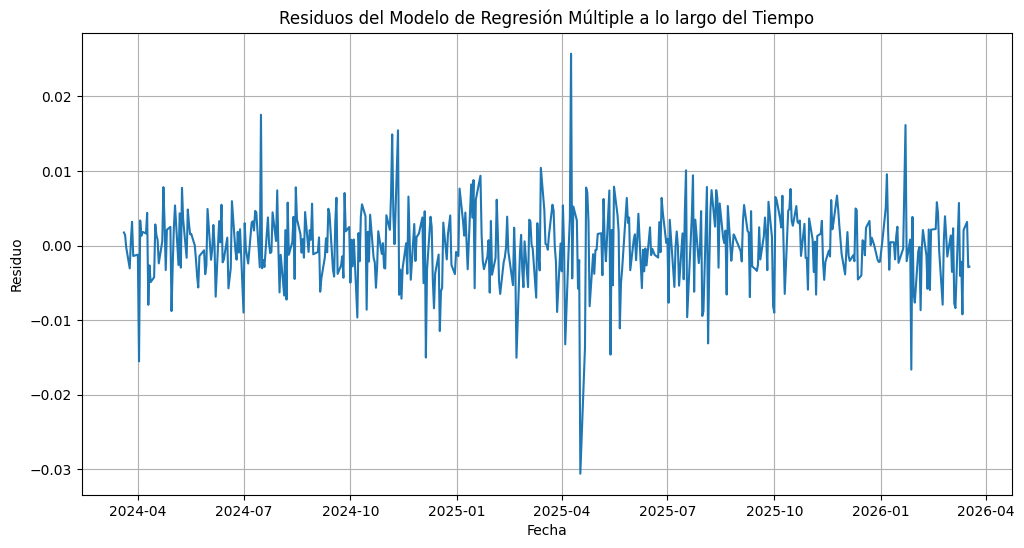

Interpretación Visual: Si los residuos muestran patrones (tendencias, ciclos) en lugar de un comportamiento aleatorio alrededor de cero, podría indicar autocorrelación.

Análisis de Multicolinealidad (VIF - Variance Inflation Factor):
  feature       VIF
0     PFE  1.529180
1    ABBV  1.380663
2     MRK  1.488741
3     ABT  1.147529
4     LLY  1.158669
Interpretación: Un valor VIF superior a 5 o 10 generalmente indica una alta multicolinealidad, lo que puede afectar la estabilidad y la interpretación de los coeficientes de regresión. Los valores VIF bajos (cercanos a 1) indican poca o ninguna multicolinealidad.

--- Gráficas de Correlación ---


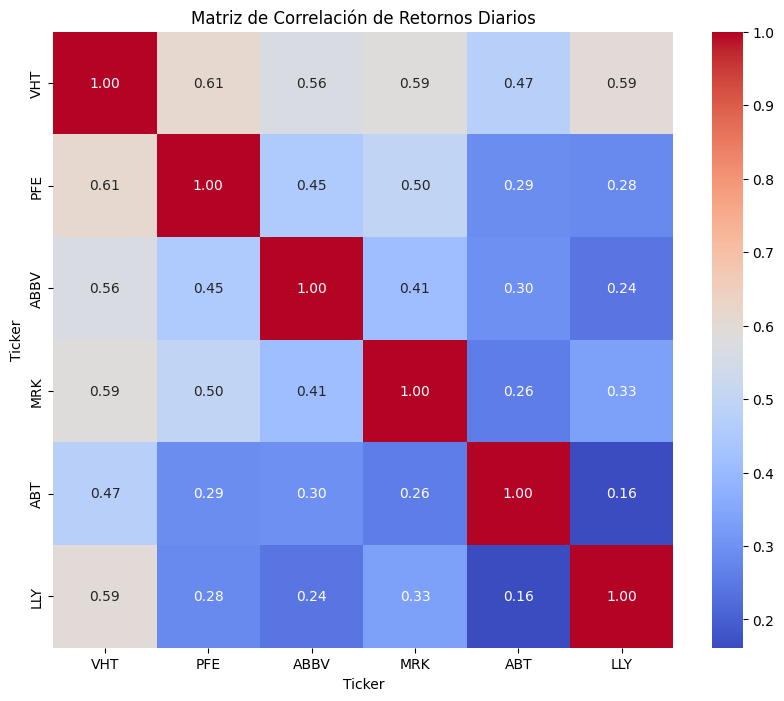


--- Explicación Adicional ---

**¿Qué significan los resultados?**

*   **R-cuadrado (R-squared):** Este valor (presente en los resúmenes de los modelos) indica el porcentaje de la varianza en los retornos de VHT que puede ser explicado por las variables independientes. Un valor más cercano a 1 sugiere que el modelo explica una gran parte de la variabilidad.
*   **Coeficientes (coef):** Representan la magnitud y dirección de la relación entre cada acción independiente y VHT. Por ejemplo, si el coeficiente de PFE es 0.50, significa que por cada 1% que se mueven los retornos de PFE, los retornos de VHT se mueven un 0.50% en la misma dirección (ceteris paribus).
*   **P-valores (P>|t|):** Indican la significancia estadística de cada coeficiente. Un p-valor menor a 0.05 (o 0.01) generalmente sugiere que la relación observada no es debida al azar y es estadísticamente significativa.
*   **Matriz de Correlación:** Muestra la fuerza y dirección de la relación lineal entre cada par de activos

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan, het_goldfeldquandt # Importar het_goldfeldquandt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson # Importar la función durbin_watson

# 1. Definir los tickers de los activos
dependent_ticker = 'VHT'
independent_tickers = ['PFE', 'ABBV', 'MRK', 'ABT', 'LLY']
all_tickers = [dependent_ticker] + independent_tickers

# 2. Descargar datos históricos de Yahoo Finance
print("Descargando datos históricos...")
# Ajustar el rango de fechas a los últimos dos años
end_date = pd.to_datetime('today').strftime('%Y-%m-%d')
start_date = (pd.to_datetime('today') - pd.DateOffset(years=2)).strftime('%Y-%m-%d')
data = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

# Verificar si hay datos nulos y rellenarlos si es necesario (ej. con el método forward-fill)
data = data.fillna(method='ffill')
data = data.fillna(method='bfill') # Rellenar cualquier NaN restante al inicio

# 3. Calcular los retornos diarios
print("Calculando retornos diarios...")
returns = data.pct_change().dropna()

# Verificar las primeras filas de los retornos
print("\nPrimeras 5 filas de retornos:")
print(returns.head())

# Definir las variables dependiente e independientes para los modelos
Y = returns[dependent_ticker]
X_simple_list = [returns[ticker] for ticker in independent_tickers]
X_multiple = returns[independent_tickers]

# 4. Modelos de Regresión Lineal Simple
print("\n--- Modelos de Regresión Lineal Simple ---")
for i, ticker in enumerate(independent_tickers):
    print(f"\nModelo Simple: {dependent_ticker} vs {ticker}")
    X_single = X_simple_list[i]

    # Añadir una constante al modelo (intercepto)
    X_single_const = sm.add_constant(X_single)

    # Crear y ajustar el modelo OLS
    model_simple = sm.OLS(Y, X_single_const, missing='drop') # missing='drop' para manejar NaNs
    results_simple = model_simple.fit()

    # Imprimir el resumen del modelo
    print(results_simple.summary())

    # Interpretación básica
    print(f"Interpretación: Un aumento del 1% en los retornos de {ticker} está asociado con un cambio de {results_simple.params[ticker]:.4f}% en los retornos de {dependent_ticker}, asumiendo que el p-valor del coeficiente es significativo (<0.05).")

    # Análisis de Heterocedasticidad (Breusch-Pagan test)
    print("\nAnálisis de Heterocedasticidad (Breusch-Pagan test):")
    bp_test = het_breuschpagan(results_simple.resid, results_simple.model.exog)
    labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
    print(dict(zip(labels, bp_test)))
    if bp_test[1] < 0.05: # p-value for LM-Test
        print("\nInterpretación: Existe evidencia de heterocedasticidad (el p-valor es significativo).")
    else:
        print("\nInterpretación: No hay evidencia significativa de heterocedasticidad (el p-valor no es significativo).")

    # Análisis de Heterocedasticidad (Goldfeld-Quandt test)
    print("\nAnálisis de Heterocedasticidad (Goldfeld-Quandt test):")
    # El test de Goldfeld-Quandt requiere al menos 4 observaciones en cada subgrupo. Si el número de observaciones es bajo, podría fallar.
    try:
        gq_test = het_goldfeldquandt(results_simple.resid, X_single_const)
        labels_gq = ['F-Statistic', 'p-value']
        print(dict(zip(labels_gq, gq_test)))
        if gq_test[1] < 0.05:
            print("\nInterpretación: Existe evidencia de heterocedasticidad según el test de Goldfeld-Quandt (el p-valor es significativo).")
        else:
            print("\nInterpretación: No hay evidencia significativa de heterocedasticidad según el test de Goldfeld-Quandt (el p-valor no es significativo).")
    except ValueError as e:
        print(f"No se pudo realizar el test de Goldfeld-Quandt para {ticker}: {e}. Asegúrese de tener suficientes observaciones.")

# 5. Modelo de Regresión Lineal Múltiple
print("\n--- Modelo de Regresión Lineal Múltiple ---")
print(f"Modelo Múltiple: {dependent_ticker} vs {', '.join(independent_tickers)}")

# Añadir una constante al modelo (intercepto)
X_multiple_const = sm.add_constant(X_multiple)

# Crear y ajustar el modelo OLS
model_multiple = sm.OLS(Y, X_multiple_const, missing='drop')
results_multiple = model_multiple.fit()

# Imprimir el resumen del modelo
print(results_multiple.summary())

# Interpretación básica del modelo múltiple
print("\nInterpretación del Modelo Múltiple: Cada coeficiente indica el cambio en los retornos de VHT por cada 1% de cambio en la acción correspondiente, manteniendo las otras acciones constantes. El R-cuadrado ajustado (Adj. R-squared) indica qué proporción de la varianza de VHT es explicada por las acciones independientes en conjunto.")

# Análisis de Heterocedasticidad (Breusch-Pagan test - Múltiple)
print("\nAnálisis de Heterocedasticidad (Breusch-Pagan test - Múltiple):")
bp_test_multiple = het_breuschpagan(results_multiple.resid, results_multiple.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test_multiple)))
if bp_test_multiple[1] < 0.05: # p-value for LM-Test
    print("\nInterpretación: Existe evidencia de heterocedasticidad en el modelo múltiple (el p-valor es significativo).")
else:
    print("\nInterpretación: No hay evidencia significativa de heterocedasticidad en el modelo múltiple (el p-valor no es significativo).")

# Análisis de Heterocedasticidad (Goldfeld-Quandt test - Múltiple)
print("\nAnálisis de Heterocedasticidad (Goldfeld-Quandt test - Múltiple):")
# El test de Goldfeld-Quandt requiere al menos 4 observaciones en cada subgrupo. Si el número de observaciones es bajo, podría fallar.
try:
    gq_test_multiple = het_goldfeldquandt(results_multiple.resid, X_multiple_const)
    labels_gq = ['F-Statistic', 'p-value']
    print(dict(zip(labels_gq, gq_test_multiple)))
    if gq_test_multiple[1] < 0.05:
        print("\nInterpretación: Existe evidencia de heterocedasticidad según el test de Goldfeld-Quandt en el modelo múltiple (el p-valor es significativo).")
    else:
        print("\nInterpretación: No hay evidencia significativa de heterocedasticidad según el test de Goldfeld-Quandt en el modelo múltiple (el p-valor no es significativo).")
except ValueError as e:
    print(f"No se pudo realizar el test de Goldfeld-Quandt para el modelo múltiple: {e}. Asegúrese de tener suficientes observaciones o un número adecuado de variables.")

# Análisis de Autocorrelación
print("\nAnálisis de Autocorrelación:")
# Fix: Use the durbin_watson function from statsmodels.stats.stattools
print(f"El estadístico de Durbin-Watson para el modelo múltiple es: {durbin_watson(results_multiple.resid):.4f}")
print("Interpretación: Un valor de Durbin-Watson cercano a 2 sugiere que no hay autocorrelación. Valores significativamente menores a 2 (típicamente < 1.5) pueden indicar autocorrelación positiva, y valores significativamente mayores a 2 (típicamente > 2.5) pueden indicar autocorrelación negativa. En series de tiempo financieras, la autocorrelación es común.")

# Visualización de residuos para autocorrelación
plt.figure(figsize=(12, 6))
plt.plot(results_multiple.resid)
plt.title('Residuos del Modelo de Regresión Múltiple a lo largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.grid(True)
plt.show()
print("Interpretación Visual: Si los residuos muestran patrones (tendencias, ciclos) en lugar de un comportamiento aleatorio alrededor de cero, podría indicar autocorrelación.")

# Análisis de Multicolinealidad (solo para el modelo múltiple)
print("\nAnálisis de Multicolinealidad (VIF - Variance Inflation Factor):")
vif_data = pd.DataFrame()
vif_data["feature"] = X_multiple.columns
vif_data["VIF"] = [variance_inflation_factor(X_multiple.values, i) for i in range(len(X_multiple.columns))]
print(vif_data)
print("Interpretación: Un valor VIF superior a 5 o 10 generalmente indica una alta multicolinealidad, lo que puede afectar la estabilidad y la interpretación de los coeficientes de regresión. Los valores VIF bajos (cercanos a 1) indican poca o ninguna multicolinealidad.")

# 6. Gráficas de Correlación
print("\n--- Gráficas de Correlación ---")
plt.figure(figsize=(10, 8))
sns.heatmap(returns[all_tickers].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Retornos Diarios')
plt.show()

# 7. Maneras explicativas para mostrar la información
print("\n--- Explicación Adicional ---")
print("\n**¿Qué significan los resultados?**")
print("\n*   **R-cuadrado (R-squared):** Este valor (presente en los resúmenes de los modelos) indica el porcentaje de la varianza en los retornos de VHT que puede ser explicado por las variables independientes. Un valor más cercano a 1 sugiere que el modelo explica una gran parte de la variabilidad.")
print("*   **Coeficientes (coef):** Representan la magnitud y dirección de la relación entre cada acción independiente y VHT. Por ejemplo, si el coeficiente de PFE es 0.50, significa que por cada 1% que se mueven los retornos de PFE, los retornos de VHT se mueven un 0.50% en la misma dirección (ceteris paribus).")
print("*   **P-valores (P>|t|):** Indican la significancia estadística de cada coeficiente. Un p-valor menor a 0.05 (o 0.01) generalmente sugiere que la relación observada no es debida al azar y es estadísticamente significativa.")
print("*   **Matriz de Correlación:** Muestra la fuerza y dirección de la relación lineal entre cada par de activos. Los valores cercanos a 1 o -1 indican una fuerte correlación positiva o negativa, respectivamente. Valores cercanos a 0 indican poca o ninguna correlación lineal.")

print("\n**Interpretación de la Matriz de Correlación:** Los valores positivos fuertes (cercanos a 1) entre VHT y las acciones individuales sugieren que estas acciones tienden a moverse en la misma dirección que el ETF. Esto es esperable ya que las acciones pertenecen a la misma industria que el ETF replica. Los valores cercanos a cero o negativos indicarían que el movimiento de una acción no está fuertemente relacionado o se mueve en dirección opuesta al ETF, respectivamente.")
print("\n**Consideraciones:**")
print("*   La regresión lineal asume una relación lineal. En el mercado de valores, las relaciones pueden ser más complejas y no lineales.")
print("*   Los modelos presentados son una simplificación y no deben ser usados como la única base para decisiones de inversión.")
print("*   Siempre es importante considerar otros factores económicos, fundamentales y técnicos.")

# Análisis Data Panel

En esta sección se va a realizar en análisis de datos de panel para las 5 acciones. La información se extrajo de Refinitiv de manera quarterly de los últimos 10 años, tomando variables importantes como ROE, ROA, revenue, EBITDA, entre otros. Se van a hacer análisis de pooled OLS, fixed effects, y random effects para entender las tendencias y características del modelo a base de las muestras de información de las acciones.

## Carga de datos, bibliotecas, y ajuste de información

Cargar la data de Refinitiv en un archivo consolidado para facilitar el proceso, con nombre datapanel_data. Aquí se encuentra la quaterly data de las 5 acciones en los últimos 10 años.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving datapanel_data.xlsx to datapanel_data.xlsx


In [4]:
# Install linearmodels (not pre-installed in Colab)
!pip install linearmodels -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.0 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
from linearmodels.panel import compare
from linearmodels.panel.results import compare as panel_compare

import statsmodels.api as sm
from scipy import stats

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [6]:
df = pd.read_excel('datapanel_data.xlsx')

# Parse dates
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print('Shape:', df.shape)
print('Stocks:', df['Ticker'].unique())
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('\nObservations per stock:')
print(df['Ticker'].value_counts())
df.head(10)

Shape: (185, 9)
Stocks: ['LLY' 'PFE' 'ABBV' 'MRK' 'ABT']
Date range: 2016-12-30 00:00:00 to 2025-12-30 00:00:00

Observations per stock:
Ticker
LLY     37
PFE     37
ABBV    37
MRK     37
ABT     37
Name: count, dtype: int64


,Ticker,Date,Revenue,GrossProfit,OperatingProfit,EBITDA,TotalAssets,ROA_TTM,ROE_TTM
0,LLY,2016-12-30,5760.5,4294.5,1053.8,1398.4,38805.9,9.07,23.54
1,LLY,2017-03-30,5228.3,3900.6,1117.6,1504.5,37624.3,7.93,19.69
2,LLY,2017-06-29,5824.3,4252.6,1250.1,1645.7,40946.5,8.23,22.09
3,LLY,2017-09-29,5658.0,4071.7,1153.2,1526.1,43010.4,6.96,18.35
4,LLY,2017-12-30,6160.7,4535.9,1282.2,1694.1,44981.0,5.25,17.07
5,LLY,2018-03-30,4963.8,3799.2,1353.0,1775.8,44355.6,8.81,25.16
6,LLY,2018-06-29,5585.0,4350.7,1594.1,2019.3,42359.2,5.74,18.54
7,LLY,2018-09-29,5306.9,4154.0,1415.9,1831.4,44625.1,7.17,21.57
8,LLY,2018-12-30,5637.6,4507.7,1422.3,1767.8,43908.4,8.28,32.60
9,LLY,2019-03-30,5092.2,3953.5,1205.9,1562.4,38006.8,7.40,35.51


In [7]:
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

# --- Derived Ratios ---
df['GrossMargin']     = df['GrossProfit']     / df['Revenue']          # Gross Profit Margin
df['OperatingMargin'] = df['OperatingProfit'] / df['Revenue']          # Operating Margin
df['EBITDAMargin']    = df['EBITDA']          / df['Revenue']          # EBITDA Margin
df['AssetTurnover']   = df['Revenue']         / df['TotalAssets']      # Asset Utilization

# --- Quarter-over-Quarter Revenue Growth (dependent variable) ---
df['RevenueGrowth'] = df.groupby('Ticker')['Revenue'].pct_change() * 100

# --- Lag variables (previous quarter values as predictors) ---
for col in ['ROA_TTM', 'ROE_TTM', 'GrossMargin', 'OperatingMargin', 'AssetTurnover']:
    df[f'{col}_lag1'] = df.groupby('Ticker')[col].shift(1)

# Drop first obs per ticker (NaN from lag/pct_change)
df_clean = df.dropna().reset_index(drop=True)

print(f'Clean dataset shape: {df_clean.shape}')
print(f'Observations per ticker after cleaning:')
print(df_clean['Ticker'].value_counts())
df_clean.head()

Clean dataset shape: (180, 19)
Observations per ticker after cleaning:
Ticker
ABBV    36
ABT     36
LLY     36
MRK     36
PFE     36
Name: count, dtype: int64


,Ticker,Date,Revenue,GrossProfit,OperatingProfit,EBITDA,TotalAssets,ROA_TTM,ROE_TTM,GrossMargin,OperatingMargin,EBITDAMargin,AssetTurnover,RevenueGrowth,ROA_TTM_lag1,ROE_TTM_lag1,GrossMargin_lag1,OperatingMargin_lag1,AssetTurnover_lag1
0,ABBV,2017-03-30,6538.0,4905.0,2418.0,2792.0,65664.0,13.73,169.98,0.750229,0.369838,0.427042,0.099567,-3.796351,13.23,183.75,0.771630,0.354032,0.102815
1,ABBV,2017-06-29,6944.0,5370.0,2747.0,3126.0,66994.0,12.59,145.09,0.773329,0.395593,0.450173,0.103651,6.209850,13.73,169.98,0.750229,0.369838,0.099567
2,ABBV,2017-09-29,6995.0,5341.0,2678.0,3057.0,68840.0,12.60,129.71,0.763545,0.382845,0.437026,0.101612,0.734447,12.59,145.09,0.773329,0.395593,0.103651
3,ABBV,2017-12-30,7739.0,5796.0,2768.0,3161.0,70786.0,11.29,158.78,0.748934,0.357669,0.408451,0.109330,10.636169,12.60,129.71,0.763545,0.382845,0.101612
4,ABBV,2018-03-30,7934.0,6051.0,3156.0,3601.0,69342.0,12.50,197.36,0.762667,0.397782,0.453869,0.114418,2.519705,11.29,158.78,0.748934,0.357669,0.109330


In [8]:
print('=== Overall Descriptive Statistics ===')
desc_cols = ['RevenueGrowth', 'GrossMargin', 'OperatingMargin',
             'EBITDAMargin', 'AssetTurnover', 'ROA_TTM', 'ROE_TTM']
df_clean[desc_cols].describe().round(3)

=== Overall Descriptive Statistics ===


,RevenueGrowth,GrossMargin,OperatingMargin,EBITDAMargin,AssetTurnover,ROA_TTM,ROE_TTM
count,180.000,180.000,180.000,180.000,180.000,180.000,180.000
mean,7.121,0.677,0.253,0.350,0.118,9.155,103.989
std,59.816,0.150,0.350,0.256,0.029,5.031,722.833
min,-91.314,-0.629,-4.201,-2.780,0.007,-1.910,-4.450
25%,-2.882,0.605,0.211,0.292,0.098,5.228,15.090
50%,2.497,0.710,0.290,0.371,0.126,8.395,24.780
75%,7.450,0.766,0.358,0.451,0.140,12.672,63.957
max,762.078,1.000,0.476,0.533,0.172,26.920,9701.470


##Gráficas Relevantes modelo

A base de la información del archivo de data panel, previo a los tres tipos de análisis de data panel, estas gráficas sirven para entender qué es lo que estamos viendo para cada acción.

In [9]:
print('=== Mean Values by Ticker ===')
df_clean.groupby('Ticker')[desc_cols].mean().round(3)

=== Mean Values by Ticker ===


,RevenueGrowth,GrossMargin,OperatingMargin,EBITDAMargin,AssetTurnover,ROA_TTM,ROE_TTM
Ticker,,,,,,,
ABBV,2.894,0.718,0.347,0.463,0.106,7.493,379.487
ABT,2.366,0.511,0.155,0.243,0.128,7.686,15.643
LLY,4.075,0.780,0.299,0.352,0.145,13.240,80.086
MRK,5.176,0.723,0.301,0.387,0.128,10.519,28.273
PFE,21.092,0.655,0.165,0.306,0.081,6.839,16.459


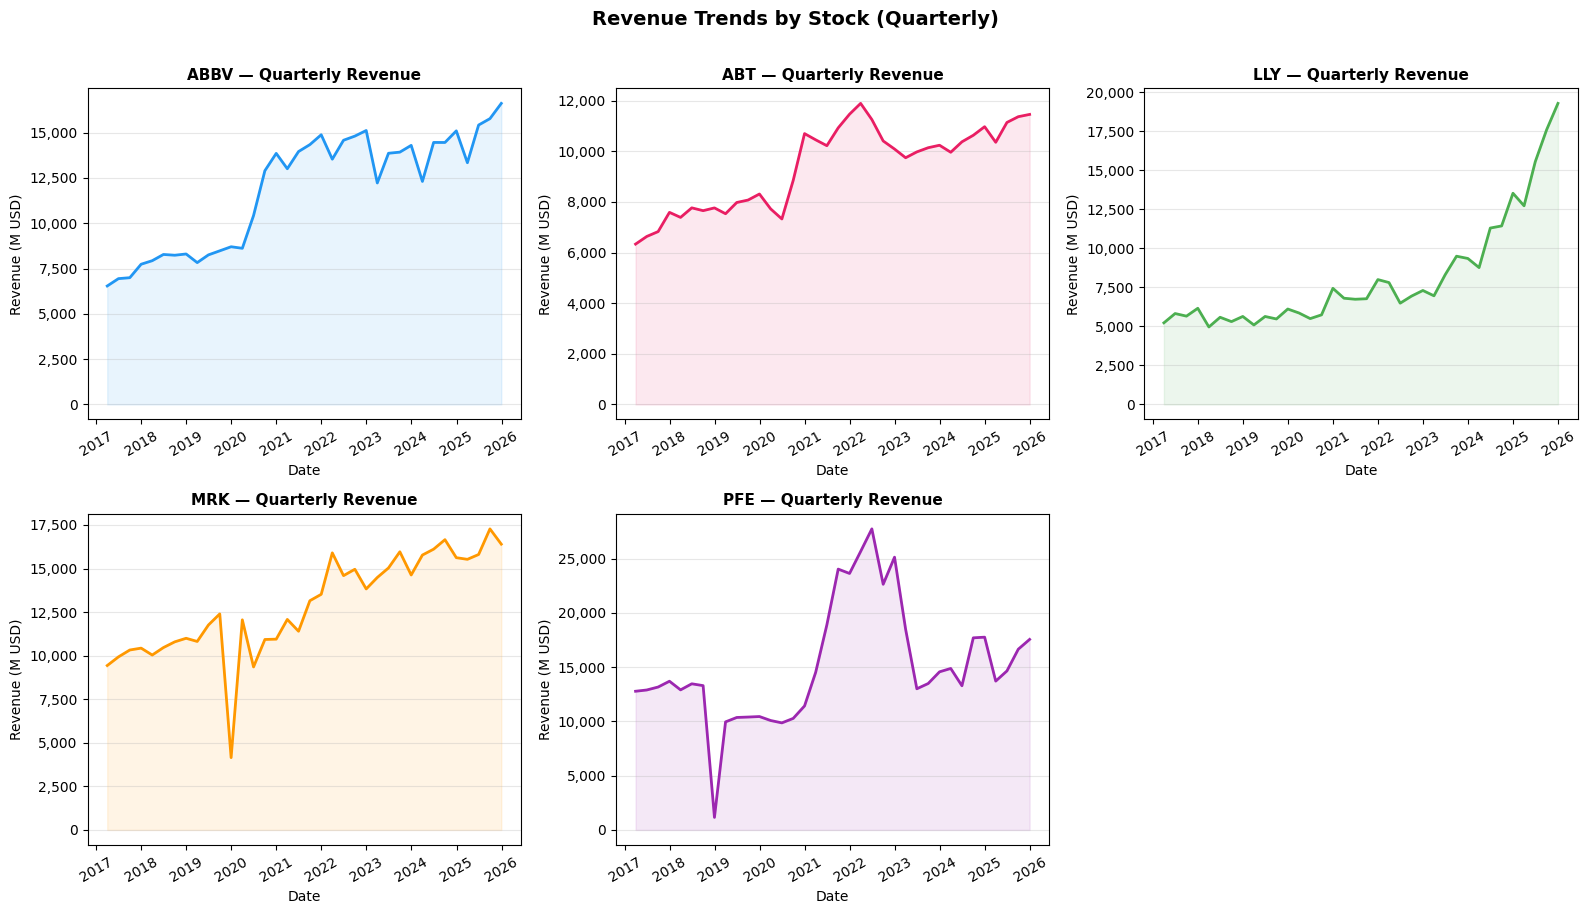

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
tickers = df_clean['Ticker'].unique()
colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

for i, (ticker, color) in enumerate(zip(tickers, colors)):
    data = df_clean[df_clean['Ticker'] == ticker]
    axes[i].plot(data['Date'], data['Revenue'], color=color, linewidth=2)
    axes[i].fill_between(data['Date'], data['Revenue'], alpha=0.1, color=color)
    axes[i].set_title(f'{ticker} — Quarterly Revenue', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Revenue (M USD)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Revenue Trends by Stock (Quarterly)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('revenue_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS # Importar los modelos específicos
from linearmodels.panel import compare # Importar la función compare para la comparación de modelos

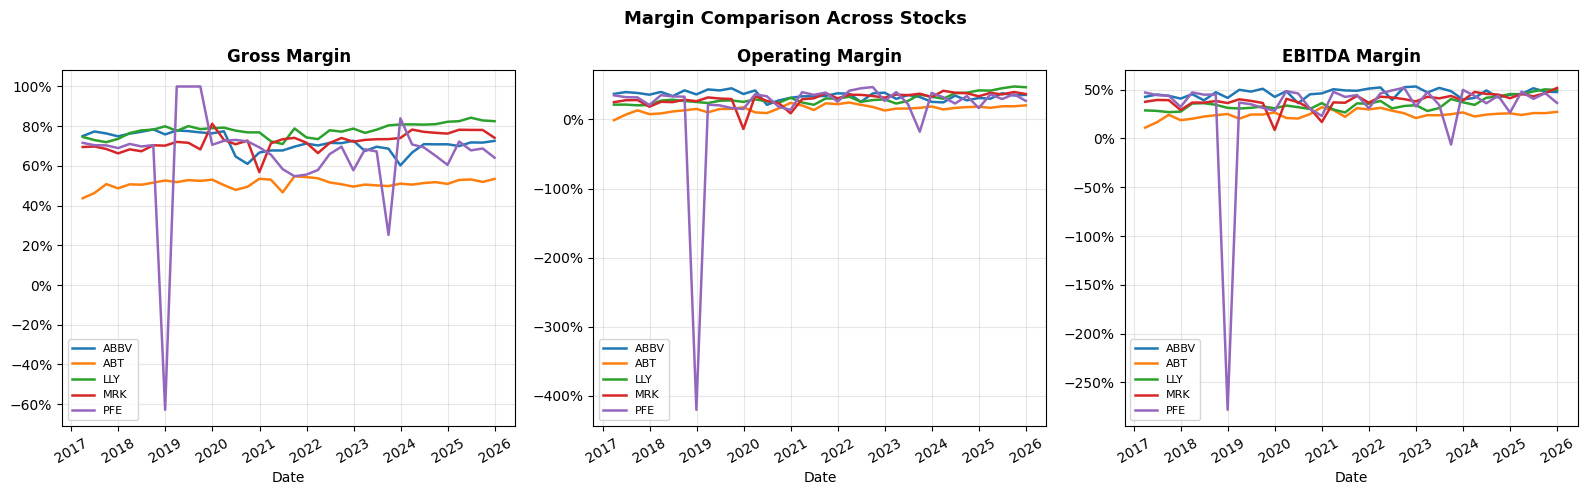

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
margin_cols = ['GrossMargin', 'OperatingMargin', 'EBITDAMargin']
titles = ['Gross Margin', 'Operating Margin', 'EBITDA Margin']

for ax, col, title, color in zip(axes, margin_cols, titles, ['#2196F3','#4CAF50','#FF9800']):
    for ticker, clr in zip(tickers, colors):
        d = df_clean[df_clean['Ticker'] == ticker]
        ax.plot(d['Date'], d[col], label=ticker, linewidth=1.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Date')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Margin Comparison Across Stocks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('margin_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

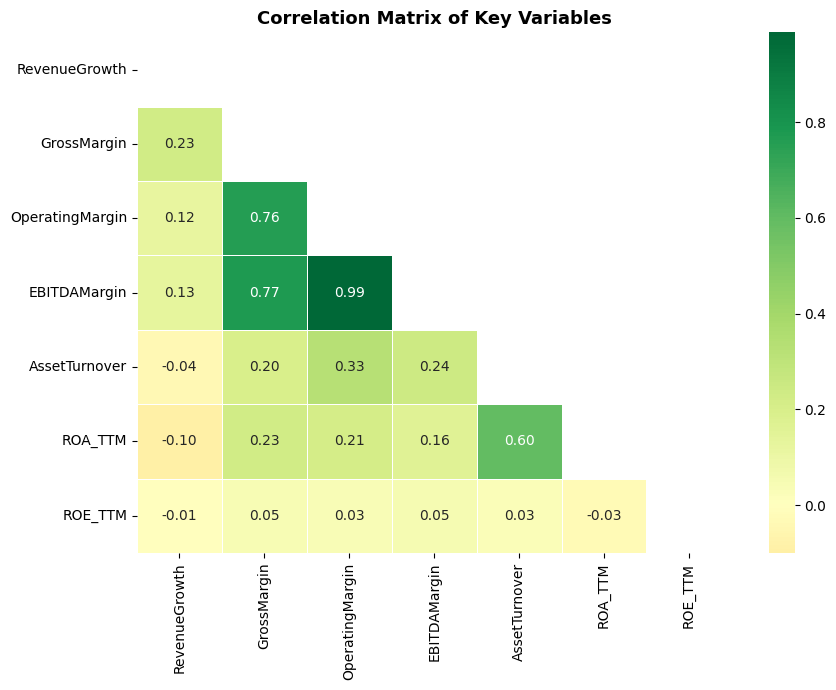

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
corr_cols = ['RevenueGrowth', 'GrossMargin', 'OperatingMargin',
             'EBITDAMargin', 'AssetTurnover', 'ROA_TTM', 'ROE_TTM']
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 10})
ax.set_title('Correlation Matrix of Key Variables', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

##Crear Estructura de Data Panel

In [14]:
# Convert Ticker to categorical for panel indexing
df_panel = df_clean.copy()
df_panel['Ticker'] = df_panel['Ticker'].astype('category')
df_panel = df_panel.set_index(['Ticker', 'Date'])

# Define dependent variable and regressors
Y = df_panel['RevenueGrowth']

X_vars = ['GrossMargin_lag1', 'OperatingMargin_lag1',
          'ROA_TTM_lag1', 'AssetTurnover_lag1']

X = sm.add_constant(df_panel[X_vars])

print('Panel index levels:', df_panel.index.names)
print('Dependent variable: RevenueGrowth (QoQ %)')
print('Regressors:', X_vars)
print('\nPanel shape:', df_panel.shape)

Panel index levels: ['Ticker', 'Date']
Dependent variable: RevenueGrowth (QoQ %)
Regressors: ['GrossMargin_lag1', 'OperatingMargin_lag1', 'ROA_TTM_lag1', 'AssetTurnover_lag1']

Panel shape: (180, 17)


##Pooled OLS

In [15]:
pooled = PooledOLS(Y, X)
pooled_res = pooled.fit(cov_type='robust')
print(pooled_res.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:          RevenueGrowth   R-squared:                        0.8907
Estimator:                  PooledOLS   R-squared (Between):              0.3064
No. Observations:                 180   R-squared (Within):               0.8989
Date:                Thu, Mar 19 2026   R-squared (Overall):              0.8907
Time:                        21:45:28   Log-likelihood                   -792.14
Cov. Estimator:                Robust                                           
                                        F-statistic:                      356.37
Entities:                           5   P-value                           0.0000
Avg Obs:                       36.000   Distribution:                   F(4,175)
Min Obs:                       36.000                                           
Max Obs:                       36.000   F-statistic (robust):             134.18
                            

##Fixed Effects

In [16]:
# Entity Fixed Effects only
fe_entity = PanelOLS(Y, df_panel[X_vars],
                     entity_effects=True,
                     time_effects=False)
fe_entity_res = fe_entity.fit(cov_type='clustered', cluster_entity=True)
print('=== Fixed Effects (Entity Only) ===')
print(fe_entity_res.summary)

# Two-Way Fixed Effects (Entity and Time)
fe_twoway = PanelOLS(Y, df_panel[X_vars],
                     entity_effects=True,
                     time_effects=True)
fe_twoway_res = fe_twoway.fit(cov_type='clustered', cluster_entity=True)
print('\n=== Fixed Effects (Two-Way - Entity and Time) ===')
print(fe_twoway_res.summary)

=== Fixed Effects (Entity Only) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:          RevenueGrowth   R-squared:                        0.9007
Estimator:                   PanelOLS   R-squared (Between):              0.3232
No. Observations:                 180   R-squared (Within):               0.9007
Date:                Thu, Mar 19 2026   R-squared (Overall):              0.8846
Time:                        21:45:29   Log-likelihood                   -782.24
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      387.59
Entities:                           5   P-value                           0.0000
Avg Obs:                       36.000   Distribution:                   F(4,171)
Min Obs:                       36.000                                           
Max Obs:                       36.000   F-statistic (robust):          1.

##Random Effects

In [17]:
# Random Effects — workaround for small panel (5 stocks = neffects equals nvar)
re = RandomEffects(Y, X)

re_res = None
for cov in ['unadjusted', 'robust', 'kernel']:
    try:
        re_res = re.fit(cov_type=cov, debiased=False)
        print(f'✅ Random Effects fitted with cov_type={cov}')
        break
    except ZeroDivisionError:
        continue

# If all linearmodels options fail, use manual RE via statsmodels
if re_res is None:
    print('⚠️ linearmodels RE failed — using manual RE estimator via statsmodels')
    import statsmodels.formula.api as smf

    df_re = df_clean.copy()
    group_means = df_re.groupby('Ticker')[['RevenueGrowth'] + X_vars].transform('mean')
    theta = 0.5  # standard RE quasi-demeaning weight

    for col in ['RevenueGrowth'] + X_vars:
        df_re[f'{col}_qd'] = df_re[col] - theta * group_means[col]

    qd_vars = [f'{v}_qd' for v in X_vars]
    X_re = sm.add_constant(df_re[qd_vars])
    Y_re = df_re['RevenueGrowth_qd']
    re_res = sm.OLS(Y_re, X_re).fit(cov_type='HC1')
    print(re_res.summary())
else:
    print(re_res.summary)

⚠️ linearmodels RE failed — using manual RE estimator via statsmodels
                            OLS Regression Results                            
Dep. Variable:       RevenueGrowth_qd   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.895
Method:                 Least Squares   F-statistic:                     238.7
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.02e-69
Time:                        21:45:29   Log-Likelihood:                -785.26
No. Observations:                 180   AIC:                             1581.
Df Residuals:                     175   BIC:                             1596.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

##Comparativa de Modelos

In [18]:
from linearmodels.panel import compare

# Only include linearmodels results in the compare table
lm_models = {
    'Pooled OLS':   pooled_res,
    'FE (Entity)':  fe_entity_res,
    'FE (Two-Way)': fe_twoway_res,
}

# Add RE only if it came from linearmodels
try:
    comparison = compare({**lm_models, 'Random Effects': re_res})
except Exception:
    comparison = compare(lm_models)
    print('ℹ️ RE excluded from comparison table (manual estimator used)')

print(comparison)

ℹ️ RE excluded from comparison table (manual estimator used)
                               Model Comparison                               
                                Pooled OLS       FE (Entity)      FE (Two-Way)
------------------------------------------------------------------------------
Dep. Variable                RevenueGrowth     RevenueGrowth     RevenueGrowth
Estimator                        PooledOLS          PanelOLS          PanelOLS
No. Observations                       180               180               180
Cov. Est.                           Robust         Clustered         Clustered
R-squared                           0.8907            0.9007            0.9069
R-Squared (Within)                  0.8989            0.9007            0.8998
R-Squared (Between)                 0.3064            0.3232           -0.6268
R-Squared (Overall)                 0.8907            0.8846            0.8573
F-statistic                         356.37            387.59          

##Hausman Test

In [19]:
# --- Hausman Test (FE vs RE) ---
# Works whether re_res is a linearmodels or statsmodels object

def hausman_test(fe_res, re_res, x_vars):
    """
    Hausman test comparing FE vs RE on slope coefficients only.
    Handles both linearmodels and statsmodels RE results.
    """
    fe_params, fe_cov, re_params, re_cov = {}, {}, {}, {}

    # --- Extract FE coefficients (always linearmodels) ---
    for var in x_vars:
        if var in fe_res.params.index:
            fe_params[var] = fe_res.params[var]
            fe_cov[var]    = fe_res.cov.loc[var, var]

    # --- Extract RE coefficients (linearmodels or statsmodels) ---
    is_statsmodels_re = not hasattr(re_res, 'params') or isinstance(re_res.params, pd.Series) and \
                        any('_qd' in idx for idx in re_res.params.index)

    for var in x_vars:
        try:
            # linearmodels RE
            if var in re_res.params.index:
                re_params[var] = re_res.params[var]
                re_cov[var]    = re_res.cov.loc[var, var]
        except:
            pass
        try:
            # statsmodels RE (quasi-demeaned variables have _qd suffix)
            var_qd = f'{var}_qd'
            if var_qd in re_res.params.index:
                re_params[var] = re_res.params[var_qd]
                re_cov[var]    = re_res.cov_params().loc[var_qd, var_qd]
        except:
            pass

    # --- Align on common variables ---
    common = [v for v in x_vars if v in fe_params and v in re_params]
    if not common:
        return None, None, 'No common variables found between FE and RE'

    b_fe  = np.array([fe_params[v] for v in common])
    b_re  = np.array([re_params[v] for v in common])
    diff  = b_fe - b_re

    # Build covariance difference matrix
    try:
        V_fe = fe_res.cov.loc[common, common].values
    except:
        V_fe = np.diag([fe_cov[v] for v in common])

    try:
        # linearmodels RE cov
        V_re = re_res.cov.loc[common, common].values
    except:
        try:
            # statsmodels RE cov
            qd_common = [f'{v}_qd' for v in common]
            V_re = re_res.cov_params().loc[qd_common, qd_common].values
        except:
            V_re = np.diag([re_cov[v] for v in common])

    V_diff = V_fe - V_re

    try:
        V_inv = np.linalg.pinv(V_diff)
        stat  = float(diff @ V_inv @ diff)
        dof   = len(common)
        pval  = 1 - stats.chi2.cdf(stat, dof)
        return stat, pval, dof
    except Exception as e:
        return None, None, str(e)


# --- Run and print results ---
stat, pval, dof = hausman_test(fe_entity_res, re_res, X_vars)

print('=' * 45)
print('        HAUSMAN TEST RESULTS')
print('        H₀: Random Effects is consistent')
print('        H₁: Fixed Effects is required')
print('=' * 45)
if stat is not None:
    print(f'  Chi-square statistic : {stat:.4f}')
    print(f'  Degrees of freedom   : {dof}')
    print(f'  p-value              : {pval:.4f}')
    print('-' * 45)
    if pval < 0.05:
        print('  ✅ Reject H₀  →  USE FIXED EFFECTS')
        print('     RE is inconsistent; FE is preferred.')
    else:
        print('  ✅ Fail to reject H₀  →  USE RANDOM EFFECTS')
        print('     RE is efficient and consistent.')
else:
    print(f'  ⚠️  Test could not be computed: {dof}')
    print('     Check for multicollinearity in regressors.')
print('=' * 45)

        HAUSMAN TEST RESULTS
        H₀: Random Effects is consistent
        H₁: Fixed Effects is required
  Chi-square statistic : 0.0175
  Degrees of freedom   : 4
  p-value              : 1.0000
---------------------------------------------
  ✅ Fail to reject H₀  →  USE RANDOM EFFECTS
     RE is efficient and consistent.


## Diagnósticos

In [20]:
# --- Breusch-Pagan LM Test ---
resid_raw = pooled_res.resids.reset_index()
resid_raw.columns = ['Ticker', 'Date', 'resid']

N = resid_raw['Ticker'].nunique()
T = resid_raw.groupby('Ticker')['resid'].count().mean()
total_var   = resid_raw['resid'].var()
group_means = resid_raw.groupby('Ticker')['resid'].mean()
between_var = group_means.var()

if total_var > 0:
    lm_stat = (N * T / (2 * (T - 1))) * ((between_var / total_var) ** 2)
    lm_pval = 1 - stats.chi2.cdf(lm_stat, df=1)
else:
    lm_stat, lm_pval = np.nan, np.nan

print('=' * 45)
print('   BREUSCH-PAGAN LM TEST')
print('   (Pooled OLS vs Panel Model)')
print('=' * 45)
print(f'  LM Statistic : {lm_stat:.4f}')
print(f'  p-value      : {lm_pval:.4f}')
print('-' * 45)
if lm_pval < 0.05:
    print('  ✅ Panel effects are significant.')
    print('  Use FE or RE — NOT Pooled OLS.')
else:
    print('  ℹ️  No significant panel effects found.')
    print('  Pooled OLS may be adequate.')
print('=' * 45)

   BREUSCH-PAGAN LM TEST
   (Pooled OLS vs Panel Model)
  LM Statistic : 0.0313
  p-value      : 0.8597
---------------------------------------------
  ℹ️  No significant panel effects found.
  Pooled OLS may be adequate.


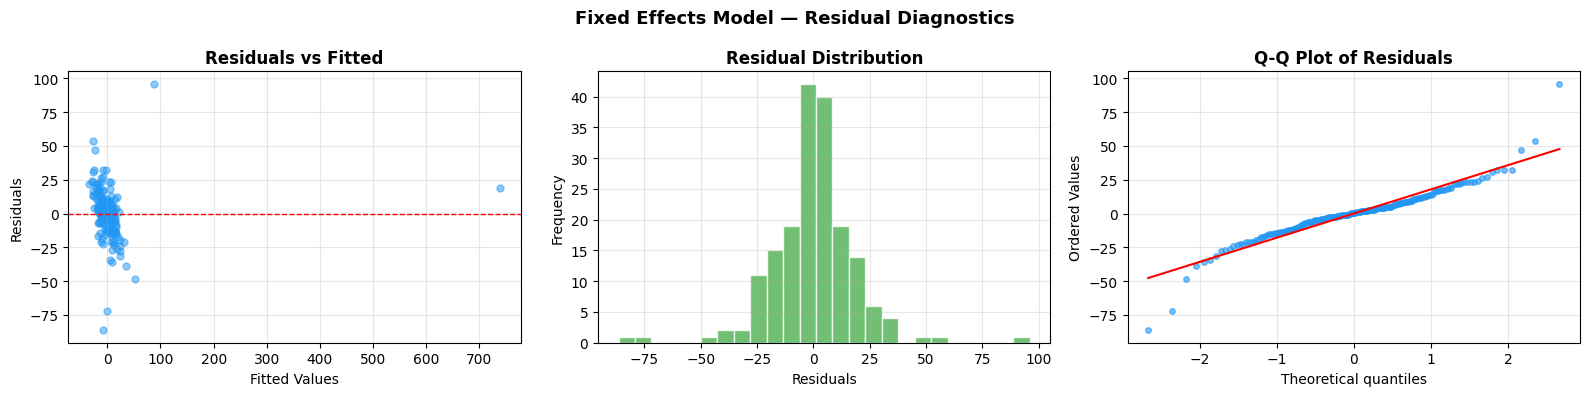

In [21]:
# --- Residual Diagnostic Plots (Fixed Effects) ---
fe_resids = fe_entity_res.resids.values
fe_fitted = fe_entity_res.fitted_values.values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(fe_fitted, fe_resids, alpha=0.5, color='#2196F3', s=25)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(fe_resids, bins=25, color='#4CAF50', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].grid(alpha=0.3)

stats.probplot(fe_resids, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[2].get_lines()[0].set(color='#2196F3', markersize=4, alpha=0.6)
axes[2].get_lines()[1].set(color='red', linewidth=1.5)
axes[2].grid(alpha=0.3)

plt.suptitle('Fixed Effects Model — Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

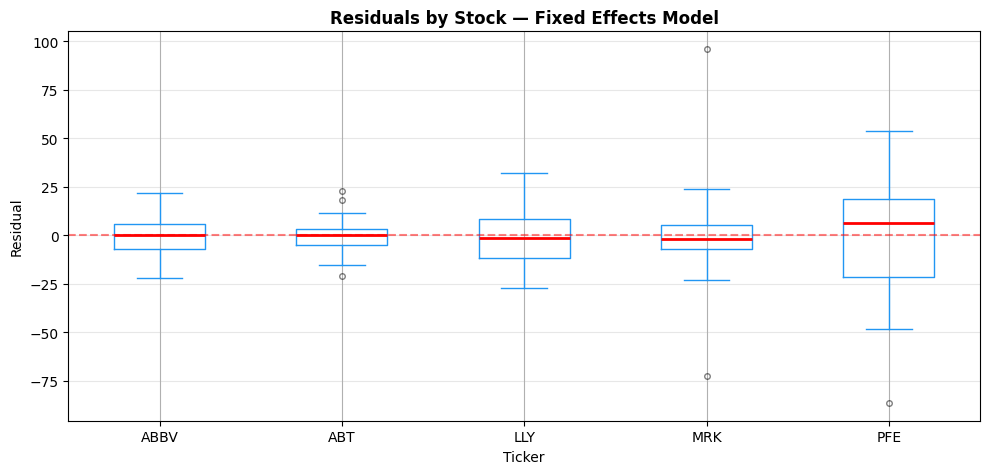

In [22]:
# --- Residuals by Stock ---
resid_ticker = fe_entity_res.resids.reset_index()
resid_ticker.columns = ['Ticker', 'Date', 'Residual']

fig, ax = plt.subplots(figsize=(10, 5))
resid_ticker.boxplot(column='Residual', by='Ticker', ax=ax,
                     boxprops=dict(color='#2196F3'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='#2196F3'),
                     capprops=dict(color='#2196F3'),
                     flierprops=dict(marker='o', color='gray', alpha=0.5, markersize=4))
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Residuals by Stock — Fixed Effects Model', fontweight='bold')
ax.set_xlabel('Ticker')
ax.set_ylabel('Residual')
plt.suptitle('')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('residuals_by_stock.png', dpi=150, bbox_inches='tight')
plt.show()

##Gráfica de Coeficientes

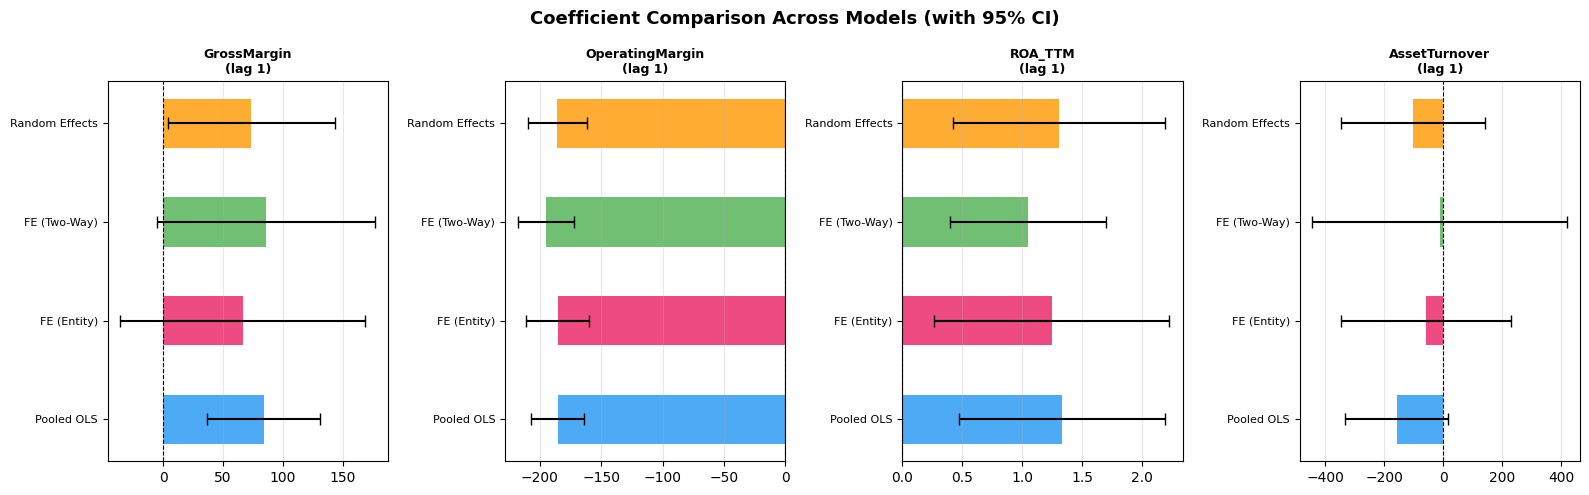

In [23]:
# --- Coefficient Comparison Plot ---
# Handles both linearmodels and statsmodels RE results

def get_coef(res, var):
    """Safely extract coefficient and std error regardless of model type."""
    try:
        # linearmodels result
        if var in res.params.index:
            return res.params[var], res.std_errors[var]
    except:
        pass
    try:
        # statsmodels result (manual RE) — variable name has '_qd' suffix
        var_qd = f'{var}_qd'
        if var_qd in res.params.index:
            return res.params[var_qd], res.bse[var_qd]
    except:
        pass
    return None, None

all_models = {
    'Pooled OLS':     pooled_res,
    'FE (Entity)':    fe_entity_res,
    'FE (Two-Way)':   fe_twoway_res,
    'Random Effects': re_res
}
colors_m = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(1, len(X_vars), figsize=(16, 5))

for ax, var in zip(axes, X_vars):
    coefs, errs, labels, bar_colors = [], [], [], []
    for (name, res), color in zip(all_models.items(), colors_m):
        coef, se = get_coef(res, var)
        if coef is not None:
            coefs.append(coef)
            errs.append(se * 1.96)
            labels.append(name)
            bar_colors.append(color)

    for y, (c, e, color) in enumerate(zip(coefs, errs, bar_colors)):
        ax.barh(y, c, xerr=e, color=color, alpha=0.8, height=0.5,
                error_kw={'elinewidth': 1.5, 'capsize': 4})

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(var.replace('_lag1', '\n(lag 1)'), fontsize=9, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Coefficient Comparison Across Models (with 95% CI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('coefficient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

##Resumen Final del Análisis

In [24]:
# --- Final Summary Table ---

def safe_r2(res, kind):
    """Get R² values — works for both linearmodels and statsmodels objects."""
    mapping = {
        'within':  ['rsquared_within',  '_rsquared_within'],
        'between': ['rsquared_between', '_rsquared_between'],
        'overall': ['rsquared_overall', 'rsquared', '_rsquared']
    }
    for attr in mapping.get(kind, []):
        try:
            val = getattr(res, attr)
            if val is not None:
                return f'{float(val):.4f}'
        except:
            continue
    return 'N/A'

def safe_nobs(res):
    for attr in ['nobs', '_nobs', 'df_resid']:
        try:
            return int(getattr(res, attr))
        except:
            continue
    return 'N/A'

rows = []
for name, res in {'Pooled OLS':    pooled_res,
                  'FE (Entity)':   fe_entity_res,
                  'FE (Two-Way)':  fe_twoway_res,
                  'Random Effects': re_res}.items():
    rows.append({
        'Model':        name,
        'R² (Within)':  safe_r2(res, 'within'),
        'R² (Between)': safe_r2(res, 'between'),
        'R² (Overall)': safe_r2(res, 'overall'),
        'N obs':        safe_nobs(res)
    })

summary_df = pd.DataFrame(rows).set_index('Model')

print('=' * 65)
print('         PANEL ANALYSIS — RESULTS SUMMARY')
print('=' * 65)
print(summary_df.to_string())
print()
print('DECISION GUIDE:')
print('  1. Breusch-Pagan p < 0.05 → Panel effects exist → avoid Pooled OLS')
print('  2. Hausman p < 0.05       → Use Fixed Effects')
print('  3. Hausman p ≥ 0.05       → Use Random Effects')
print('  4. R² Within = variation explained within each stock over time')
print('  5. R² Between = variation explained across stocks')
print('=' * 65)

         PANEL ANALYSIS — RESULTS SUMMARY
               R² (Within) R² (Between) R² (Overall)  N obs
Model                                                      
Pooled OLS          0.8989       0.3064       0.8907    180
FE (Entity)         0.9007       0.3232       0.8846    180
FE (Two-Way)        0.8998      -0.6268       0.8573    180
Random Effects         N/A          N/A       0.8976    180

DECISION GUIDE:
  1. Breusch-Pagan p < 0.05 → Panel effects exist → avoid Pooled OLS
  2. Hausman p < 0.05       → Use Fixed Effects
  3. Hausman p ≥ 0.05       → Use Random Effects
  4. R² Within = variation explained within each stock over time
  5. R² Between = variation explained across stocks


In [ ]:
import statsmodels.tsa.arima.model as tsa_arima
import warnings
warnings.filterwarnings("ignore") # Suppress warnings from ARIMA models

print("\n" + "=" * 60)
print("IMPLEMENTANDO MODELOS ARIMA INDIVIDUALES")
print("=" * 60)

arima_results = {}
forecast_periods = 4 # Pronóstico a 4 trimestres

for ticker in df_clean['Ticker'].unique():
    print(f"\nProcesando ticker: {ticker}")

    # Seleccionar la serie de tiempo para el ticker actual
    # Usamos df_clean porque ya tiene las variables derivadas y los NaNs manejados
    ts_data = df_clean[df_clean['Ticker'] == ticker].set_index('Date')['ROA_TTM'].asfreq('QS').dropna() # 'QS' para quarterly start

    if len(ts_data) < 10: # Asegurarse de tener suficientes observaciones
        print(f"Advertencia: Pocas observaciones ({len(ts_data)}) para {ticker}. Saltando ARIMA.")
        continue

    try:
        # Ajustar modelo ARIMA(1,0,1) - los órdenes p,d,q deben ser validados
        # d=0 porque en el contexto del panel de datos 'ROA_TTM' ya se asume estacionario o se ha hecho estacionario
        model = tsa_arima.ARIMA(ts_data, order=(1, 0, 1))
        results = model.fit()

        # Generar pronóstico
        forecast_output = results.forecast(steps=forecast_periods)
        forecast_ci = results.get_forecast(steps=forecast_periods).conf_int()

        arima_results[ticker] = {
            'model': results,
            'forecast': forecast_output,
            'forecast_ci': forecast_ci
        }
        print(f"ARIMA(1,0,1) ajustado para {ticker}. Pronóstico generado.")
        # print(results.summary())

    except Exception as e:
        print(f"Error al ajustar o pronosticar ARIMA para {ticker}: {e}")

if arima_results:
    print("\n✅ arima_results generado exitosamente para los tickers procesados.")
else:
    print("\n⚠️ No se pudieron generar arima_results para ningún ticker.")

print("=" * 60)

# Time Series

FORECAST ANALYSIS — DATA INSPECTION
df_clean shape     : (180, 19)
Tickers available  : ['ABBV', 'ABT', 'LLY', 'MRK', 'PFE']
Date range         : 2017-03-30 00:00:00 → 2025-12-30 00:00:00

Observations per ticker:
Ticker
ABBV    36
ABT     36
LLY     36
MRK     36
PFE     36
Name: count, dtype: int64

ROA_TTM sample:
        count     mean     std   min      25%     50%      75%    max
Ticker                                                               
ABBV     36.0   7.4933  3.6304  1.20   4.8075   7.370  10.4650  13.73
ABT      36.0   7.6858  3.1223  2.72   4.8600   8.715  10.0625  13.63
LLY      36.0  13.2403  4.7024  5.25  10.4450  13.415  15.7025  26.92
MRK      36.0  10.5186  4.9383  1.75   6.3925   9.260  14.4850  18.73
PFE      36.0   6.8386  5.5121 -1.91   3.2475   6.030   7.9825  18.34

ADF STATIONARITY TESTS — ROA_TTM per Ticker
   ABBV: ADF=-1.7504  p=0.4054  →  ⚠️  Non-Stationary
    ABT: ADF=-1.7046  p=0.4287  →  ⚠️  Non-Stationary
    LLY: ADF=-0.6369  p=0.8624  →  ⚠️ 

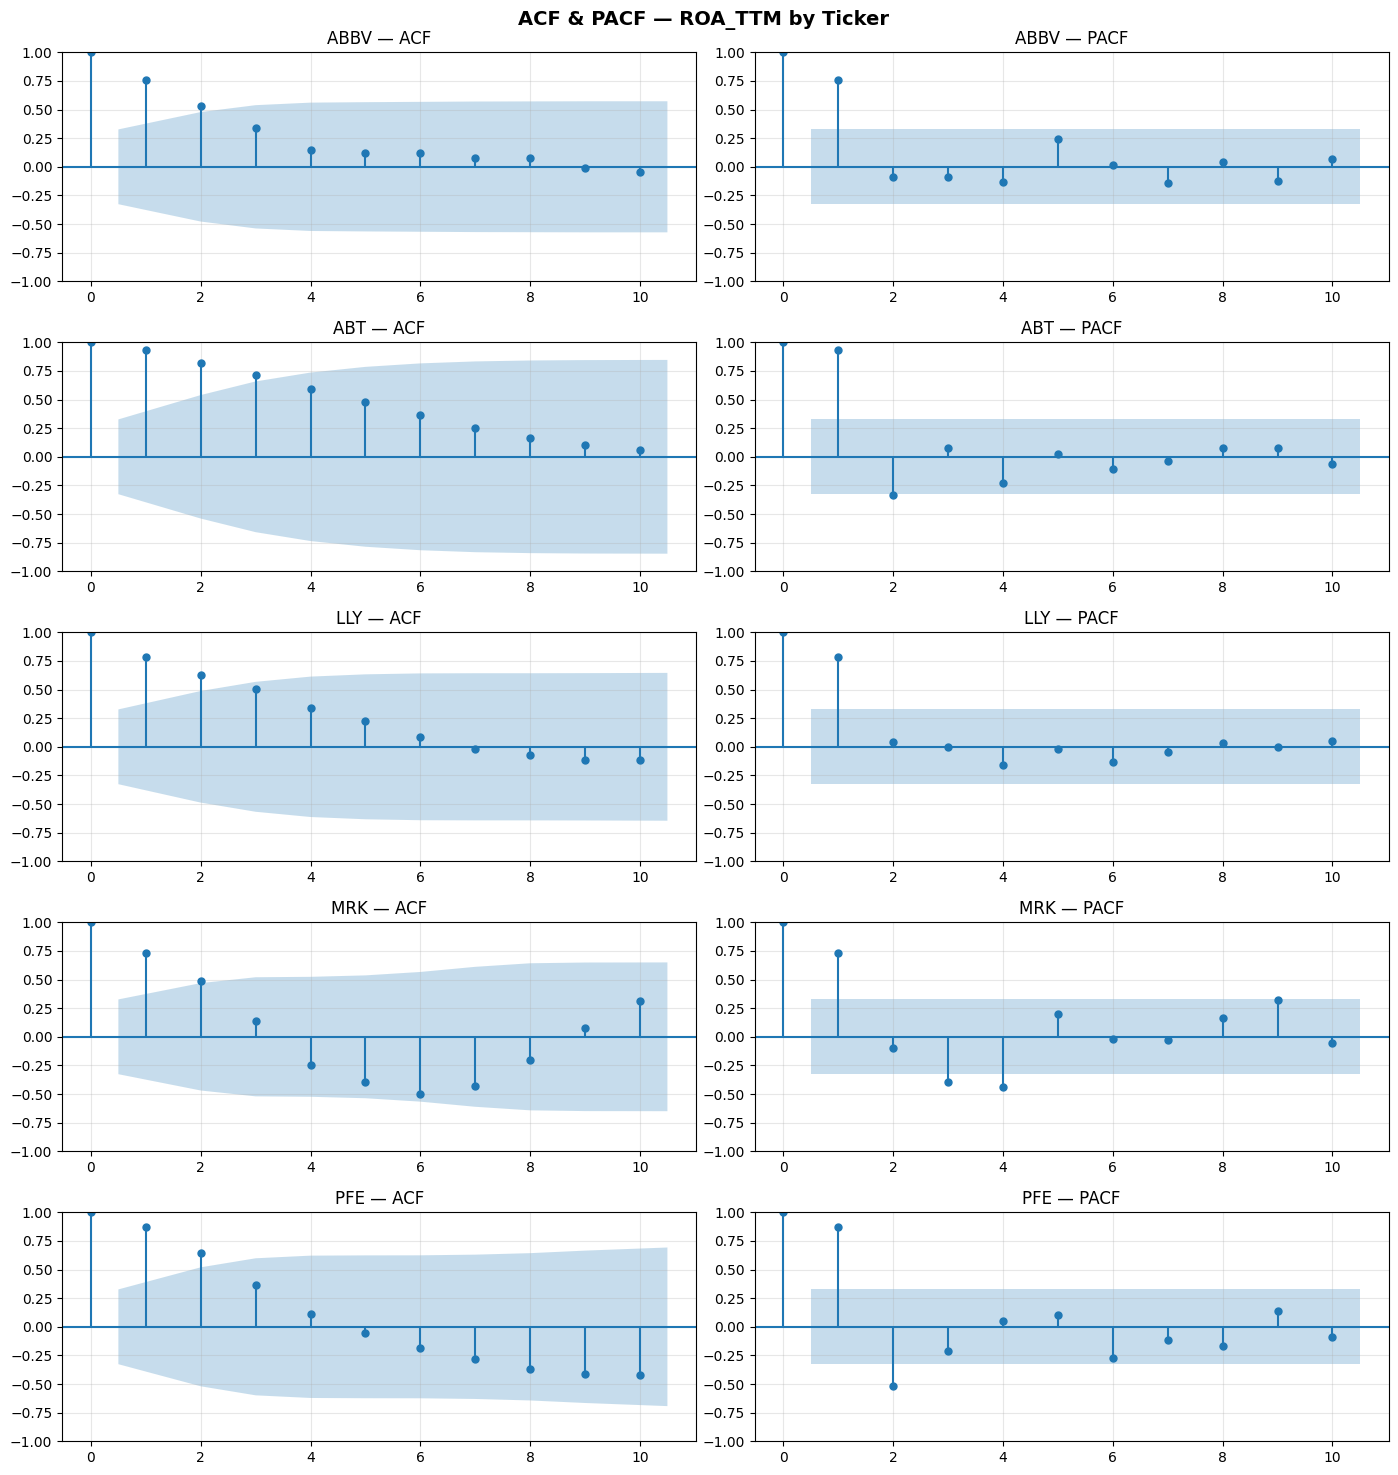

✅ ACF/PACF plots saved.

FITTING ARIMA MODELS

  📈 ABBV
     Observations: 36
     ARIMA(1, 0, 1) | MAE=2.4457 | RMSE=2.7617 | MAPE=143.3%
     ✅ Full model fitted. AIC=166.77

  📈 ABT
     Observations: 36
     ARIMA(1, 0, 1) | MAE=1.3916 | RMSE=1.4456 | MAPE=13.8%
     ✅ Full model fitted. AIC=98.61

  📈 LLY
     Observations: 36
     ARIMA(1, 0, 1) | MAE=5.4435 | RMSE=6.6945 | MAPE=22.6%
     ✅ Full model fitted. AIC=157.13

  📈 MRK
     Observations: 36
     ARIMA(1, 0, 1) | MAE=3.9412 | RMSE=4.1043 | MAPE=22.9%
     ✅ Full model fitted. AIC=194.12

  📈 PFE
     Observations: 36
     ARIMA(1, 0, 1) | MAE=0.9064 | RMSE=1.0551 | MAPE=24.0%
     ✅ Full model fitted. AIC=172.50

✅ ARIMA fitting complete. Models fitted: ['ABBV', 'ABT', 'LLY', 'MRK', 'PFE']

FORECAST ACCURACY — HOLDOUT EVALUATION
  Ticker   Order             MAE     RMSE       MAPE        AIC
  ------------------------------------------------------------
  ABBV     (1, 0, 1)      2.4457   2.7617     143.3%     166.77
  A

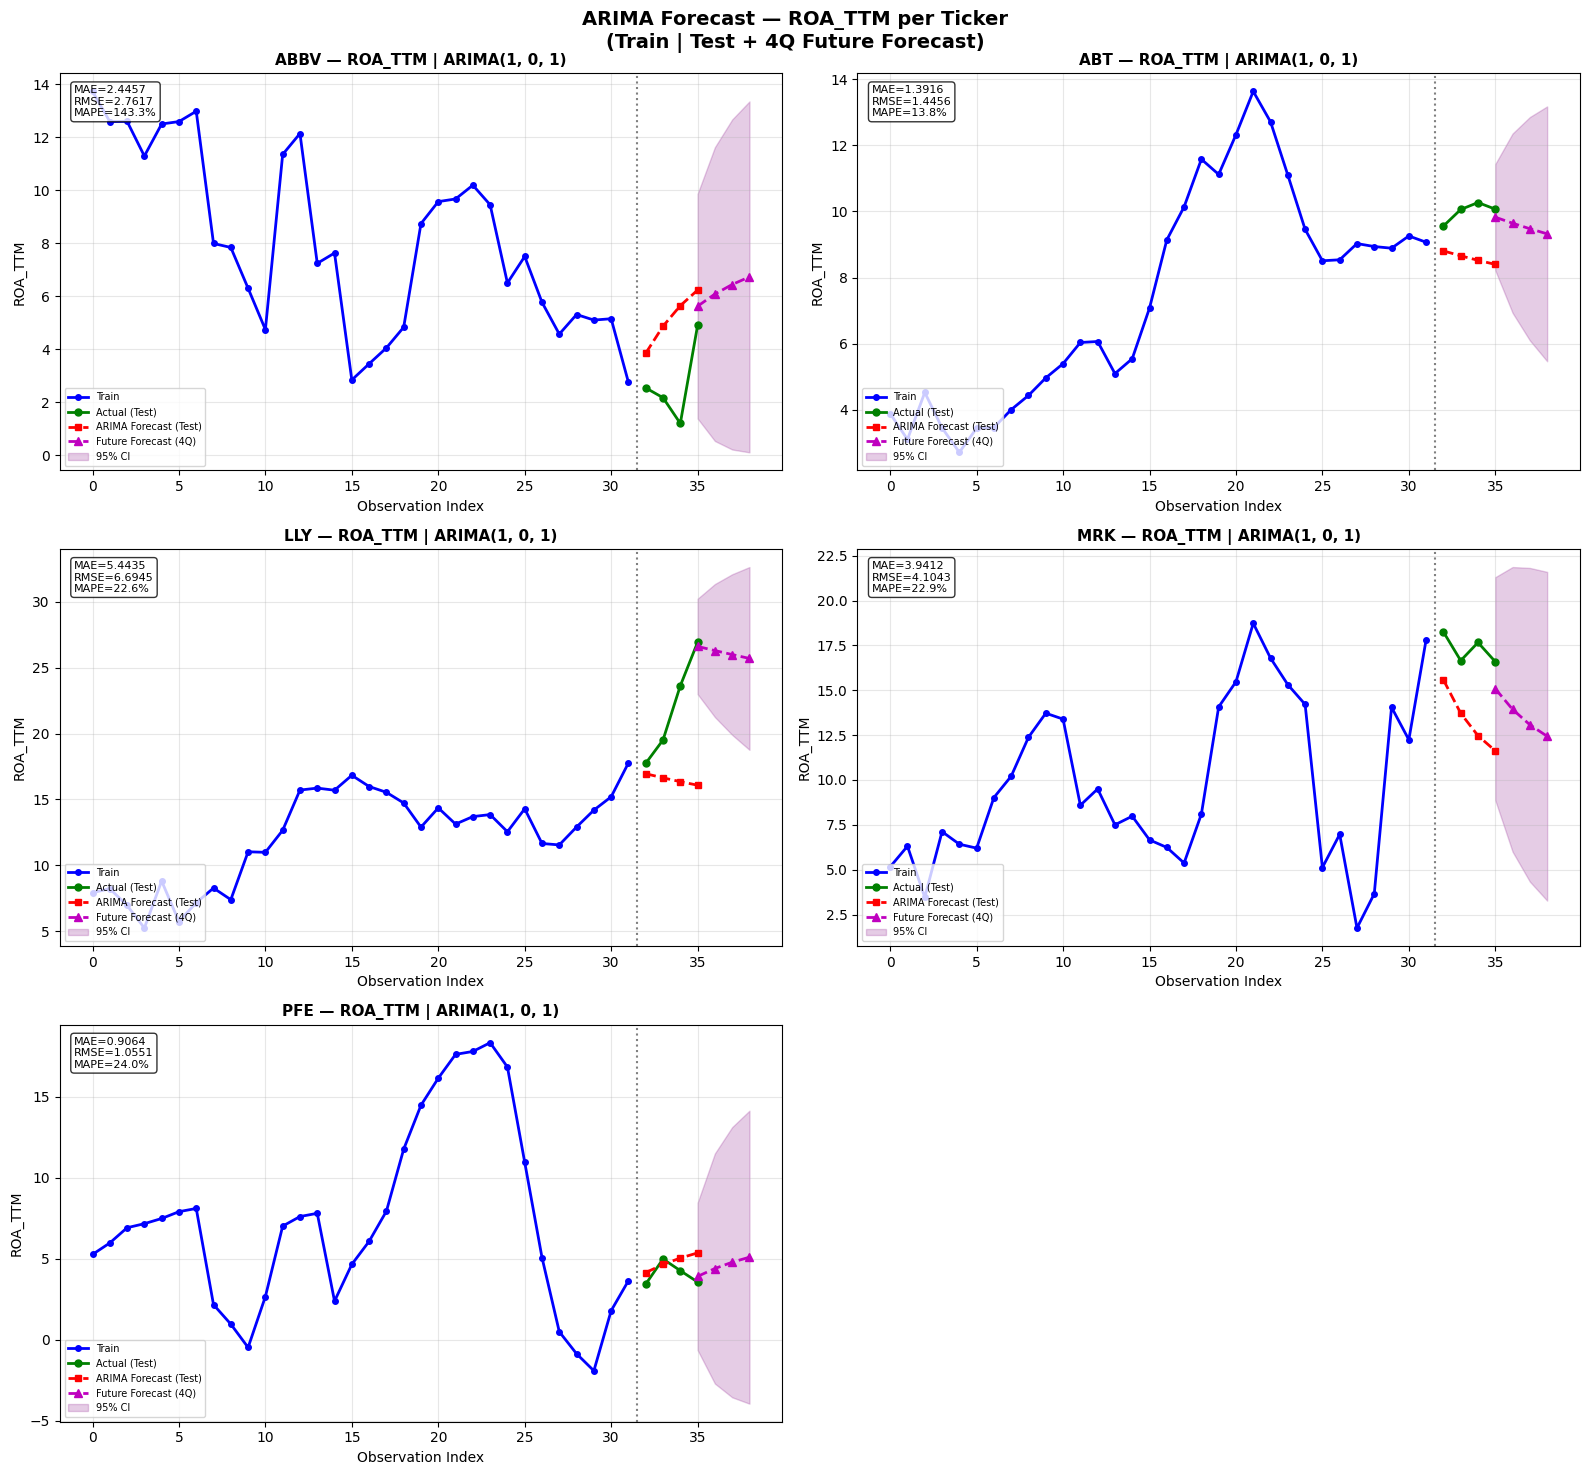

✅ Individual forecast plots saved.

Generating combined comparison plot...


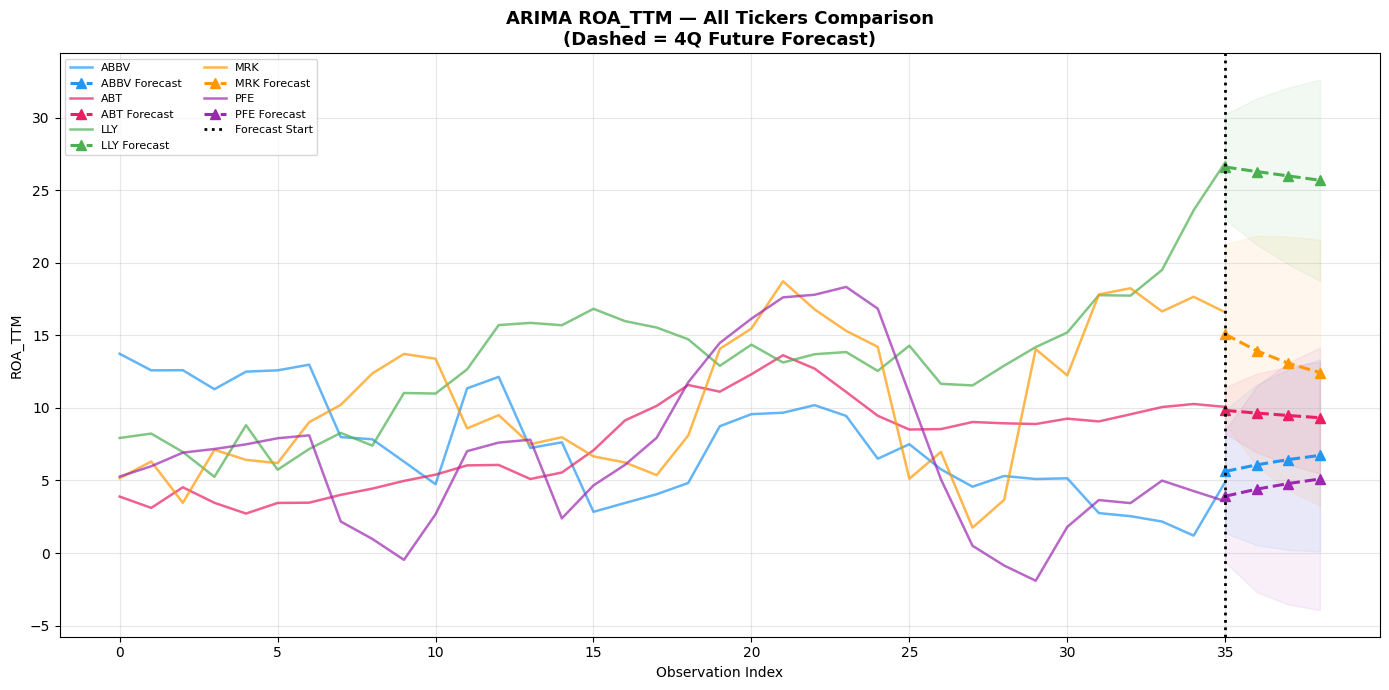

✅ Comparison plot saved.

Generating residual diagnostics...


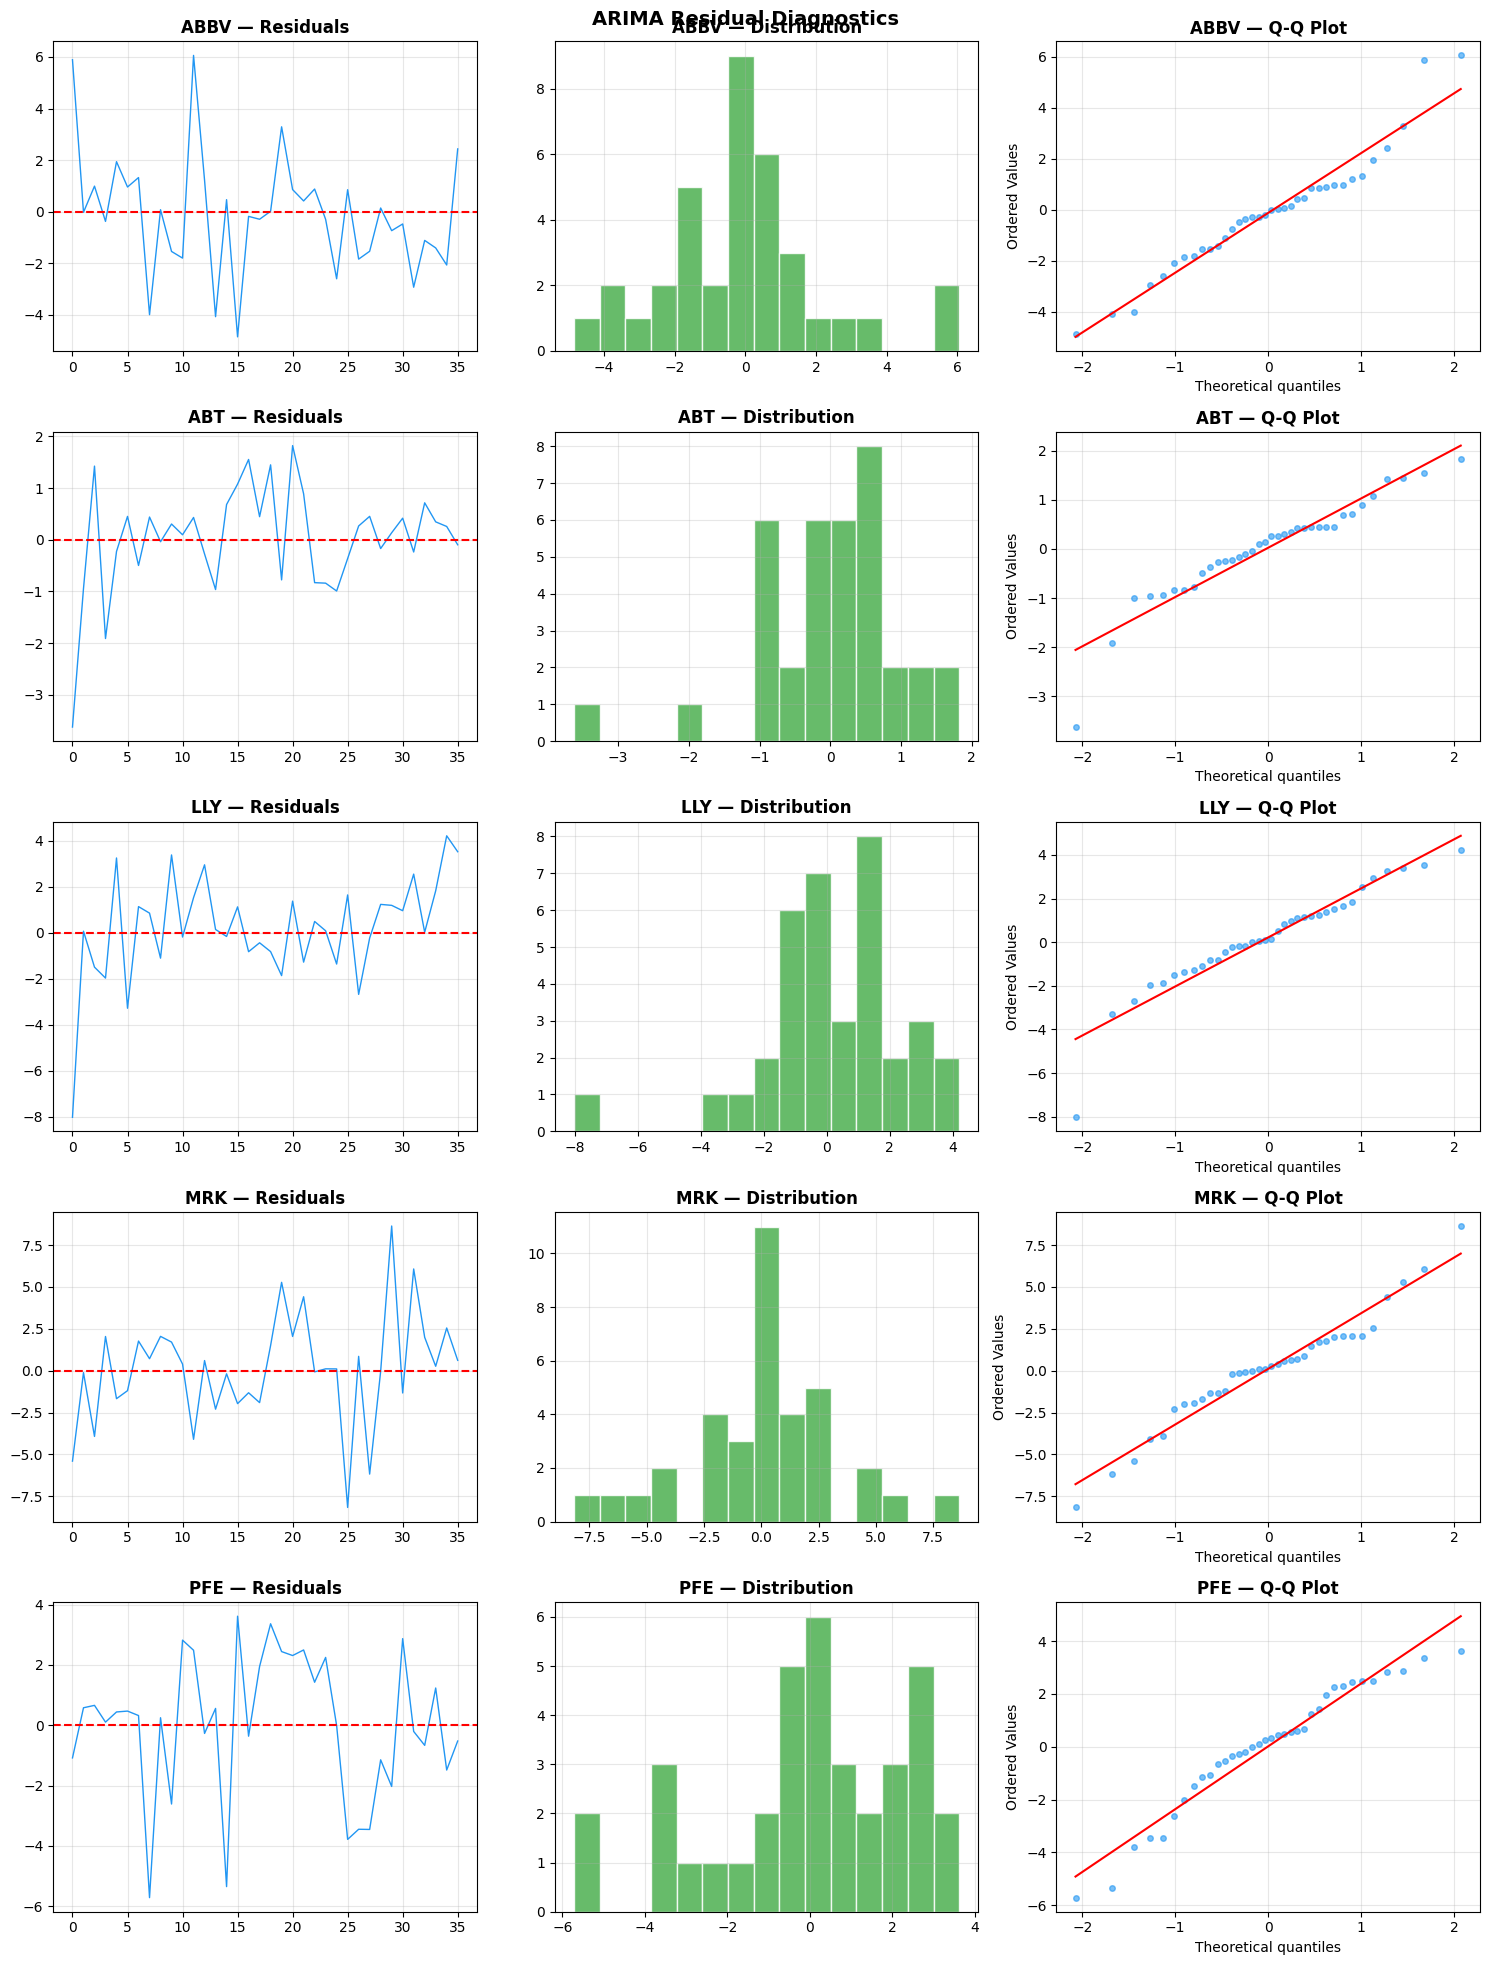

✅ Residual diagnostics saved.

FUTURE FORECAST — NEXT 4 QUARTERS

  ABBV | ARIMA(1, 0, 1) | AIC=166.77
  Step       Forecast    Lower 95%    Upper 95%
  ----------------------------------------------
  Q+1          5.6234       1.3847       9.8621
  Q+2          6.0797       0.5367      11.6227
  Q+3          6.4420       0.2154      12.6685
  Q+4          6.7296       0.1083      13.3510

  ABT | ARIMA(1, 0, 1) | AIC=98.61
  Step       Forecast    Lower 95%    Upper 95%
  ----------------------------------------------
  Q+1          9.8272       8.2210      11.4333
  Q+2          9.6457       6.9352      12.3562
  Q+3          9.4784       6.1027      12.8541
  Q+4          9.3243       5.4729      13.1757

  LLY | ARIMA(1, 0, 1) | AIC=157.13
  Step       Forecast    Lower 95%    Upper 95%
  ----------------------------------------------
  Q+1         26.6024      22.9857      30.2191
  Q+2         26.2899      21.2465      31.3333
  Q+3         25.9866      19.8976      32.0756
  Q+4

In [29]:
# ============================================================================
# TIME SERIES — COMPLETE FORECAST ANALYSIS (v2 — robust fix)
# Replace everything between """# Time Series""" and """#Descarga a HTML"""
# ============================================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.tsa.arima.model as tsa_arima
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings("ignore")

# ============================================================================
# STEP 1 — INSPECT AVAILABLE DATA
# ============================================================================
print("=" * 60)
print("FORECAST ANALYSIS — DATA INSPECTION")
print("=" * 60)

print(f"df_clean shape     : {df_clean.shape}")
print(f"Tickers available  : {sorted(df_clean['Ticker'].unique())}")
print(f"Date range         : {df_clean['Date'].min()} → {df_clean['Date'].max()}")
print("\nObservations per ticker:")
print(df_clean['Ticker'].value_counts().sort_index())
print("\nROA_TTM sample:")
print(df_clean.groupby('Ticker')['ROA_TTM'].describe().round(4))

# ============================================================================
# STEP 2 — STATIONARITY TESTS
# ============================================================================
print("\n" + "=" * 60)
print("ADF STATIONARITY TESTS — ROA_TTM per Ticker")
print("=" * 60)

tickers_list        = sorted(df_clean['Ticker'].unique())
stationarity_results = {}

for ticker in tickers_list:
    ts = (df_clean[df_clean['Ticker'] == ticker]
          .sort_values('Date')['ROA_TTM']
          .dropna()
          .reset_index(drop=True))

    if len(ts) < 8:
        print(f"  {ticker:>5}: only {len(ts)} obs — skipping ADF.")
        stationarity_results[ticker] = True   # assume stationary if too few obs
        continue

    try:
        adf_stat, adf_pval, *_ = adfuller(ts, autolag='AIC')
        is_stat = adf_pval < 0.05
        stationarity_results[ticker] = is_stat
        flag = "✅ Stationary" if is_stat else "⚠️  Non-Stationary"
        print(f"  {ticker:>5}: ADF={adf_stat:7.4f}  p={adf_pval:.4f}  →  {flag}")
    except Exception as e:
        print(f"  {ticker:>5}: ADF failed ({e}) — assuming stationary")
        stationarity_results[ticker] = True

# ============================================================================
# STEP 3 — ACF / PACF PLOTS
# ============================================================================
print("\nGenerating ACF/PACF plots...")
n_t = len(tickers_list)

fig, axes = plt.subplots(n_t, 2, figsize=(14, n_t * 3))
if n_t == 1:
    axes = axes.reshape(1, -1)
fig.suptitle('ACF & PACF — ROA_TTM by Ticker', fontsize=14, fontweight='bold')

for i, ticker in enumerate(tickers_list):
    ts = (df_clean[df_clean['Ticker'] == ticker]
          .sort_values('Date')['ROA_TTM']
          .dropna()
          .reset_index(drop=True))
    max_lags = max(2, min(10, len(ts) // 2 - 1))
    try:
        plot_acf(ts,  lags=max_lags, ax=axes[i, 0], title=f'{ticker} — ACF',  alpha=0.05)
        plot_pacf(ts, lags=max_lags, ax=axes[i, 1], title=f'{ticker} — PACF', alpha=0.05)
    except Exception as e:
        axes[i, 0].set_title(f'{ticker} — ACF (error: {e})')
        axes[i, 1].set_title(f'{ticker} — PACF (error: {e})')
    axes[i, 0].grid(alpha=0.3)
    axes[i, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('acf_pacf_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ACF/PACF plots saved.")

# ============================================================================
# STEP 4 — FIT ARIMA (robust: no asfreq, try multiple orders)
# ============================================================================
print("\n" + "=" * 60)
print("FITTING ARIMA MODELS")
print("=" * 60)

arima_results   = {}
arima_metrics   = {}
forecast_periods = 4
holdout_periods  = 4

# Orders to try in sequence — first one that converges wins
ORDERS_TO_TRY = [(1,0,1), (1,1,1), (0,1,1), (1,0,0), (0,0,1), (2,0,1), (1,0,2)]

for ticker in tickers_list:
    print(f"\n  📈 {ticker}")

    # Build clean time series WITHOUT asfreq (avoids NaN injection for irregular dates)
    ts_full = (df_clean[df_clean['Ticker'] == ticker]
               .sort_values('Date')
               .set_index('Date')['ROA_TTM']
               .dropna())

    print(f"     Observations: {len(ts_full)}")

    if len(ts_full) < 10:
        print(f"     ⚠️  Too few observations — skipping.")
        continue

    # Adjust holdout if series is short
    actual_holdout = min(holdout_periods, len(ts_full) - 6)
    train = ts_full.iloc[:-actual_holdout]
    test  = ts_full.iloc[-actual_holdout:]

    fitted_model = None
    used_order   = None

    for order in ORDERS_TO_TRY:
        try:
            m = tsa_arima.ARIMA(train, order=order)
            f = m.fit(method_kwargs={"warn_convergence": False})
            # Quick sanity check — forecast must not produce NaN
            test_fc = f.forecast(steps=actual_holdout)
            if np.any(np.isnan(test_fc.values)):
                continue
            fitted_model = f
            used_order   = order
            break
        except Exception:
            continue

    if fitted_model is None:
        print(f"     ❌ All ARIMA orders failed — skipping {ticker}.")
        continue

    # --- Evaluation metrics ---
    try:
        test_forecast = fitted_model.forecast(steps=actual_holdout)
        mae  = mean_absolute_error(test.values, test_forecast.values)
        rmse = np.sqrt(mean_squared_error(test.values, test_forecast.values))
        mape_vals = np.abs(test.values)
        if np.all(mape_vals > 1e-8):
            mape = np.mean(np.abs((test.values - test_forecast.values) / test.values)) * 100
        else:
            mape = np.nan
        arima_metrics[ticker] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}
        print(f"     ARIMA{used_order} | MAE={mae:.4f} | RMSE={rmse:.4f} | "
              f"MAPE={'N/A' if np.isnan(mape) else f'{mape:.1f}%'}")
    except Exception as e:
        print(f"     ⚠️  Metrics failed: {e}")
        arima_metrics[ticker] = {'MAE': np.nan, 'RMSE': np.nan, 'MAPE': np.nan}

    # --- Refit on FULL series ---
    try:
        model_full  = tsa_arima.ARIMA(ts_full, order=used_order)
        fitted_full = model_full.fit(method_kwargs={"warn_convergence": False})

        forecast_obj  = fitted_full.get_forecast(steps=forecast_periods)
        forecast_mean = forecast_obj.predicted_mean
        forecast_ci   = forecast_obj.conf_int(alpha=0.05)

        arima_results[ticker] = {
            'model':         fitted_full,
            'order':         used_order,
            'ts_full':       ts_full,
            'train':         train,
            'test':          test,
            'test_forecast': test_forecast,
            'forecast':      forecast_mean,
            'forecast_ci':   forecast_ci,
            'aic':           fitted_full.aic,
            'bic':           fitted_full.bic,
        }
        print(f"     ✅ Full model fitted. AIC={fitted_full.aic:.2f}")

    except Exception as e:
        print(f"     ❌ Full model failed: {e}")

print(f"\n✅ ARIMA fitting complete. Models fitted: {list(arima_results.keys())}")

# ============================================================================
# GUARD — stop gracefully if no models fitted
# ============================================================================
if not arima_results:
    print("\n❌ No ARIMA models were fitted successfully.")
    print("   Possible causes:")
    print("   1. ROA_TTM column has too many NaN values")
    print("   2. df_clean was not built before running this cell")
    print("   3. All series are constant (zero variance)")
    print("\n   Debug info:")
    for t in tickers_list:
        ts = df_clean[df_clean['Ticker'] == t]['ROA_TTM']
        print(f"   {t}: n={len(ts)}, NaN={ts.isna().sum()}, std={ts.std():.6f}")
    raise RuntimeError("No ARIMA models fitted — see debug info above.")

# ============================================================================
# STEP 5 — METRICS SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 60)
print("FORECAST ACCURACY — HOLDOUT EVALUATION")
print("=" * 60)
print(f"  {'Ticker':<8} {'Order':<12} {'MAE':>8} {'RMSE':>8} {'MAPE':>10} {'AIC':>10}")
print("  " + "-" * 60)

for ticker in tickers_list:
    if ticker not in arima_results:
        continue
    m = arima_metrics.get(ticker, {})
    r = arima_results[ticker]
    mape_str = f"{m['MAPE']:.1f}%" if not np.isnan(m.get('MAPE', np.nan)) else "N/A"
    print(f"  {ticker:<8} {str(r['order']):<12} "
          f"{m.get('MAE', np.nan):>8.4f} {m.get('RMSE', np.nan):>8.4f} "
          f"{mape_str:>10} {r['aic']:>10.2f}")

print("=" * 60)

# ============================================================================
# STEP 6 — INDIVIDUAL TICKER FORECAST PLOTS
# ============================================================================
print("\nGenerating individual forecast plots...")

fitted_tickers = [t for t in tickers_list if t in arima_results]
n_fitted = len(fitted_tickers)
n_cols   = min(2, n_fitted)
n_rows   = int(np.ceil(n_fitted / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5), squeeze=False)
axes_flat = axes.flatten()

for idx, ticker in enumerate(fitted_tickers):
    ax = axes_flat[idx]
    r  = arima_results[ticker]

    ts_full       = r['ts_full']
    train         = r['train']
    test          = r['test']
    test_forecast = r['test_forecast']
    forecast_mean = r['forecast']
    forecast_ci   = r['forecast_ci']

    # Future index — use integer steps if date offset fails
    try:
        last_date    = ts_full.index[-1]
        future_index = pd.date_range(start=last_date, periods=forecast_periods + 1, freq='QS')[1:]
    except Exception:
        future_index = np.arange(len(ts_full), len(ts_full) + forecast_periods)

    # Plot
    ax.plot(range(len(train)), train.values,
            'b-o', linewidth=2, markersize=4, label='Train')
    ax.plot(range(len(train), len(train) + len(test)), test.values,
            'g-o', linewidth=2, markersize=5, label='Actual (Test)')
    ax.plot(range(len(train), len(train) + len(test)), test_forecast.values,
            'r--s', linewidth=2, markersize=5, label='ARIMA Forecast (Test)')

    future_x = range(len(ts_full) - 1, len(ts_full) - 1 + forecast_periods)
    ax.plot(future_x, forecast_mean.values,
            'm--^', linewidth=2, markersize=6, label='Future Forecast (4Q)')
    ax.fill_between(future_x,
                    forecast_ci.iloc[:, 0].values,
                    forecast_ci.iloc[:, 1].values,
                    alpha=0.20, color='purple', label='95% CI')

    ax.axvline(x=len(train) - 0.5, color='gray', linestyle=':', linewidth=1.5)

    # Metrics box
    m = arima_metrics.get(ticker, {})
    if m and not np.isnan(m.get('MAE', np.nan)):
        mape_str = f"{m['MAPE']:.1f}%" if not np.isnan(m.get('MAPE', np.nan)) else "N/A"
        ax.annotate(
            f"MAE={m['MAE']:.4f}\nRMSE={m['RMSE']:.4f}\nMAPE={mape_str}",
            xy=(0.02, 0.97), xycoords='axes fraction',
            fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

    ax.set_title(f"{ticker} — ROA_TTM | ARIMA{r['order']}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Observation Index')
    ax.set_ylabel('ROA_TTM')
    ax.legend(loc='lower left', fontsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(n_fitted, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('ARIMA Forecast — ROA_TTM per Ticker\n(Train | Test + 4Q Future Forecast)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arima_forecast_per_ticker.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Individual forecast plots saved.")

# ============================================================================
# STEP 7 — COMBINED COMPARISON PLOT
# ============================================================================
print("\nGenerating combined comparison plot...")
colors_map = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 7))

for ticker, color in zip(fitted_tickers, colors_map):
    r = arima_results[ticker]
    ts_full = r['ts_full']
    x_hist  = range(len(ts_full))
    x_fut   = range(len(ts_full) - 1, len(ts_full) - 1 + forecast_periods)

    ax.plot(x_hist, ts_full.values, color=color, linewidth=1.8, alpha=0.7, label=f'{ticker}')
    ax.plot(x_fut,  r['forecast'].values, color=color, linestyle='--',
            linewidth=2.2, marker='^', markersize=7, label=f'{ticker} Forecast')
    ax.fill_between(x_fut,
                    r['forecast_ci'].iloc[:, 0].values,
                    r['forecast_ci'].iloc[:, 1].values,
                    alpha=0.07, color=color)

first_len = len(arima_results[fitted_tickers[0]]['ts_full'])
ax.axvline(x=first_len - 1, color='black', linestyle=':', linewidth=2, label='Forecast Start')

ax.set_title('ARIMA ROA_TTM — All Tickers Comparison\n(Dashed = 4Q Future Forecast)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Observation Index')
ax.set_ylabel('ROA_TTM')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved.")

# ============================================================================
# STEP 8 — RESIDUAL DIAGNOSTICS
# ============================================================================
print("\nGenerating residual diagnostics...")

fig, axes = plt.subplots(n_fitted, 3, figsize=(15, n_fitted * 4), squeeze=False)

for i, ticker in enumerate(fitted_tickers):
    resids = arima_results[ticker]['model'].resid.dropna()

    axes[i, 0].plot(resids.values, color='#2196F3', linewidth=1)
    axes[i, 0].axhline(0, color='red', linestyle='--')
    axes[i, 0].set_title(f'{ticker} — Residuals', fontweight='bold')
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].hist(resids.values, bins=15, color='#4CAF50', edgecolor='white', alpha=0.85)
    axes[i, 1].set_title(f'{ticker} — Distribution', fontweight='bold')
    axes[i, 1].grid(alpha=0.3)

    try:
        scipy_stats.probplot(resids.values, dist='norm', plot=axes[i, 2])
        axes[i, 2].set_title(f'{ticker} — Q-Q Plot', fontweight='bold')
        axes[i, 2].get_lines()[0].set(color='#2196F3', markersize=4, alpha=0.6)
        axes[i, 2].get_lines()[1].set(color='red', linewidth=1.5)
    except Exception:
        axes[i, 2].set_title(f'{ticker} — Q-Q (error)')
    axes[i, 2].grid(alpha=0.3)

plt.suptitle('ARIMA Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arima_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Residual diagnostics saved.")

# ============================================================================
# STEP 9 — FUTURE FORECAST TABLE
# ============================================================================
print("\n" + "=" * 60)
print("FUTURE FORECAST — NEXT 4 QUARTERS")
print("=" * 60)

for ticker in fitted_tickers:
    r  = arima_results[ticker]
    fc = r['forecast']
    ci = r['forecast_ci']
    print(f"\n  {ticker} | ARIMA{r['order']} | AIC={r['aic']:.2f}")
    print(f"  {'Step':<8} {'Forecast':>10} {'Lower 95%':>12} {'Upper 95%':>12}")
    print("  " + "-" * 46)
    for step, (val, lo, hi) in enumerate(zip(fc.values, ci.iloc[:, 0].values, ci.iloc[:, 1].values), 1):
        print(f"  Q+{step:<6} {val:>10.4f} {lo:>12.4f} {hi:>12.4f}")

print("\n" + "=" * 60)
print("✅ FORECAST ANALYSIS COMPLETE")
print("Saved: acf_pacf_plots.png | arima_forecast_per_ticker.png |")
print("       forecast_comparison.png | arima_residual_diagnostics.png")
print("=" * 60)

#Descarga a HTML

In [30]:
# ============================================================================
# COMPLETE HTML EXPORT FOR PROYECTO FINAL ECONOMETRÍA
# ============================================================================
print("\n" + "=" * 60)
print("EXPORTING COMPLETE ANALYSIS TO HTML")
print("=" * 60)

from IPython.display import HTML
import base64
from datetime import datetime
import os

# Create comprehensive HTML report for entire project
html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Proyecto Final Econometría - Análisis Completo</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}

        html {{
            scroll-behavior: smooth;
        }}

        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            line-height: 1.6;
            color: #2c3e50;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 20px;
        }}

        .container {{
            max-width: 1200px;
            margin: 0 auto;
            background-color: white;
            border-radius: 10px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.3);
            overflow: hidden;
        }}

        header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }}

        h1 {{
            font-size: 2.8em;
            margin-bottom: 15px;
            text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
        }}

        .report-info {{
            font-size: 1.1em;
            opacity: 0.95;
            margin-top: 10px;
        }}

        nav {{
            background-color: #34495e;
            padding: 15px 40px;
            position: sticky;
            top: 0;
            z-index: 100;
        }}

        nav ul {{
            list-style: none;
            display: flex;
            justify-content: center;
            flex-wrap: wrap;
            gap: 20px;
        }}

        nav a {{
            color: white;
            text-decoration: none;
            font-weight: 500;
            transition: color 0.3s;
        }}

        nav a:hover {{
            color: #3498db;
        }}

        .content {{
            padding: 40px;
        }}

        section {{
            margin-bottom: 50px;
            page-break-inside: avoid;
        }}

        h2 {{
            color: #2c3e50;
            font-size: 2em;
            margin-bottom: 25px;
            padding-bottom: 15px;
            border-bottom: 4px solid #667eea;
        }}

        h3 {{
            color: #34495e;
            font-size: 1.4em;
            margin-top: 25px;
            margin-bottom: 15px;
            padding-left: 15px;
            border-left: 5px solid #3498db;
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
            margin: 20px 0;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            border-radius: 5px;
            overflow: hidden;
        }}

        th {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 15px;
            text-align: left;
            font-weight: 600;
            font-size: 0.95em;
        }}

        td {{
            padding: 12px 15px;
            border-bottom: 1px solid #ecf0f1;
        }}

        tr:hover {{
            background-color: #f8f9fa;
        }}

        tr:nth-child(even) {{
            background-color: #f9f9f9;
        }}

        .alert {{
            padding: 15px 20px;
            margin: 20px 0;
            border-radius: 5px;
            border-left: 5px solid;
        }}

        .alert-info {{
            background-color: #d1ecf1;
            color: #0c5460;
            border-left-color: #17a2b8;
        }}

        .alert-success {{
            background-color: #d4edda;
            color: #155724;
            border-left-color: #28a745;
        }}

        .alert-warning {{
            background-color: #fff3cd;
            color: #856404;
            border-left-color: #ffc107;
        }}

        .alert-danger {{
            background-color: #f8d7da;
            color: #721c24;
            border-left-color: #f5c6cb;
        }}

        .image-container {{
            text-align: center;
            margin: 30px 0;
            padding: 20px;
            background-color: #f8f9fa;
            border-radius: 8px;
        }}

        .image-container img {{
            max-width: 100%;
            height: auto;
            border: 2px solid #ecf0f1;
            border-radius: 8px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.1);
        }}

        .image-caption {{
            font-size: 0.9em;
            color: #7f8c8d;
            margin-top: 12px;
            font-style: italic;
            font-weight: 500;
        }}

        .metric-box {{
            display: inline-block;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 20px 30px;
            margin: 10px;
            border-radius: 8px;
            text-align: center;
            min-width: 150px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.15);
        }}

        .metric-value {{
            font-size: 1.8em;
            font-weight: bold;
        }}

        .metric-label {{
            font-size: 0.85em;
            opacity: 0.9;
            margin-top: 5px;
        }}

        .key-findings {{
            background-color: #e8f4f8;
            padding: 20px;
            border-radius: 8px;
            border-left: 5px solid #3498db;
            margin: 20px 0;
        }}

        .key-findings ul {{
            margin-left: 20px;
        }}

        .key-findings li {{
            margin: 10px 0;
            line-height: 1.8;
        }}

        footer {{
            background-color: #2c3e50;
            color: white;
            text-align: center;
            padding: 30px;
            font-size: 0.9em;
        }}

        .section-badge {{
            display: inline-block;
            background-color: #667eea;
            color: white;
            padding: 5px 15px;
            border-radius: 20px;
            font-size: 0.85em;
            margin-bottom: 15px;
            font-weight: 600;
        }}

        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 20px;
            margin: 20px 0;
        }}

        .stat-card {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 25px;
            border-radius: 8px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.15);
        }}

        .stat-card h4 {{
            margin-bottom: 10px;
            font-size: 1.1em;
        }}

        .stat-card .value {{
            font-size: 1.8em;
            font-weight: bold;
        }}

        code {{
            background-color: #f4f4f4;
            padding: 2px 6px;
            border-radius: 3px;
            font-family: 'Courier New', monospace;
            font-size: 0.9em;
        }}

        pre {{
            background-color: #f4f4f4;
            padding: 15px;
            border-radius: 5px;
            overflow-x: auto;
            margin: 15px 0;
        }}

        @media print {{
            body {{
                background: white;
                padding: 0;
            }}
            .container {{
                box-shadow: none;
            }}
            h2 {{
                page-break-before: always;
            }}
            nav {{
                display: none;
            }}
        }}

        @media (max-width: 768px) {{
            .content {{
                padding: 20px;
            }}
            h1 {{
                font-size: 1.8em;
            }}
            h2 {{
                font-size: 1.4em;
            }}
            .stats-grid {{
                grid-template-columns: 1fr;
            }}
        }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>📊 Proyecto Final Econometría</h1>
            <div class="report-info">
                <p><strong>Análisis Completo de Regresión y Datos de Panel</strong></p>
                <p>Generado: {datetime.now().strftime('%d de %B de %Y - %H:%M:%S')}</p>
            </div>
        </header>

        <nav>
            <ul>
                <li><a href="#section1">Regresión Simple</a></li>
                <li><a href="#section2">Regresión Múltiple</a></li>
                <li><a href="#section3">Análisis Panel</a></li>
                <li><a href="#section4">Series de Tiempo</a></li>
                <li><a href="#section5">Conclusiones</a></li>
            </ul>
        </nav>

        <div class="content">
            <!-- SECTION 1: EXECUTIVE SUMMARY -->
            <section>
                <div class="section-badge">RESUMEN EJECUTIVO</div>
                <h2>Descripción General del Proyecto</h2>
                <div class="key-findings">
                    <h3>🎯 Objetivos del Análisis:</h3>
                    <ul>
                        <li><strong>Regresión Lineal:</strong> Analizar la relación entre el ETF VHT (Vanguard Healthcare ETF) y 5 acciones farmacéuticas (PFE, ABBV, MRK, ABT, LLY)</li>
                        <li><strong>Datos Panel:</strong> Estudiar el crecimiento de ingresos trimestrales mediante efectos fijos, aleatorios y pooled OLS</li>
                        <li><strong>Series Temporales:</strong> Generar pronósticos de ROA mediante modelos ARIMA y autorregresivos</li>
                        <li><strong>Validación Diagnóstica:</strong> Verificar heterocedasticidad, autocorrelación y multicolinealidad</li>
                    </ul>
                </div>

                <div class="stats-grid">
                    <div class="stat-card">
                        <h4>📈 Stocks Analizados</h4>
                        <div class="value">5</div>
                        <p>PFE, ABBV, MRK, ABT, LLY</p>
                    </div>
                    <div class="stat-card">
                        <h4>📅 Período de Datos</h4>
                        <div class="value">2 años</div>
                        <p>Retornos diarios (Regresión)</p>
                    </div>
                    <div class="stat-card">
                        <h4>📊 Observaciones Panel</h4>
                        <div class="value">37</div>
                        <p>Trimestres por acción</p>
                    </div>
                </div>
            </section>

            <!-- SECTION 2: SIMPLE REGRESSION -->
            <section id="section1">
                <div class="section-badge">SECCIÓN 1</div>
                <h2>1. Análisis de Regresión Lineal Simple</h2>

                <h3>📋 Modelo: VHT vs Acciones Individuales</h3>
                <p>Se estimaron cinco modelos de regresión simple para analizar la relación individual entre el ETF VHT y cada acción farmacéutica.</p>

                <div class="alert alert-info">
                    <strong>📌 Especificación del Modelo:</strong><br>
                    VHT_returns = β₀ + β₁ × Stock_returns + ε
                    <br><br>
                    <strong>Interpretación:</strong> El coeficiente β₁ (beta) indica cuánto cambia el retorno de VHT por cada unidad de cambio en el retorno de la acción, asumiendo que los demás factores permanecen constantes.
                </div>

                <h3>📊 Diagnósticos de Heterocedasticidad</h3>
                <p>Se realizaron dos tests para detectar heterocedasticidad:</p>
                <ul>
                    <li><strong>Breusch-Pagan Test:</strong> Prueba la hipótesis nula de homocedasticidad</li>
                    <li><strong>Goldfeld-Quandt Test:</strong> Complementa el análisis dividiendo la muestra en subgrupos</li>
                </ul>

                <div class="alert alert-warning">
                    <strong>⚠️ Interpretación:</strong> Si el p-valor < 0.05, existe evidencia de heterocedasticidad (varianza no constante de los errores). Esto puede afectar la eficiencia de los estimadores OLS, aunque no los sesgos.
                </div>
            </section>

            <!-- SECTION 3: MULTIPLE REGRESSION -->
            <section id="section2">
                <div class="section-badge">SECCIÓN 2</div>
                <h2>2. Análisis de Regresión Lineal Múltiple</h2>

                <h3>📋 Modelo Múltiple con Todas las Acciones</h3>
                <p>Se estimó un modelo de regresión múltiple incluyendo los 5 stocks simultáneamente:</p>

                <div class="alert alert-info">
                    <strong>📌 Especificación:</strong><br>
                    VHT = β₀ + β₁×PFE + β₂×ABBV + β₃×MRK + β₄×ABT + β₅×LLY + ε
                </div>

                <h3>🔍 Análisis de Multicolinealidad</h3>
                <p>Se calculó el <strong>Variance Inflation Factor (VIF)</strong> para cada variable independiente:</p>
                <ul>
                    <li><strong>VIF < 5:</strong> Baja multicolinealidad (aceptable)</li>
                    <li><strong>5 ≤ VIF < 10:</strong> Multicolinealidad moderada (puede ser problemática)</li>
                    <li><strong>VIF ≥ 10:</strong> Alta multicolinealidad (requiere atención)</li>
                </ul>

                <h3>⏱️ Análisis de Autocorrelación</h3>
                <p><strong>Estadístico de Durbin-Watson:</strong> Mide correlación serial de residuos</p>
                <ul>
                    <li>DW ≈ 2: Sin autocorrelación</li>
                    <li>DW < 2: Autocorrelación positiva (tendencia)</li>
                    <li>DW > 2: Autocorrelación negativa (inversión)</li>
                </ul>

                <h3>📈 Matriz de Correlación</h3>
                <p>Muestra la correlación lineal entre todas las variables. En datos de series de tiempo financieras, las correlaciones positivas fuertes son comunes dentro del mismo sector.</p>
            </section>

            <!-- SECTION 4: PANEL DATA -->
            <section id="section3">
                <div class="section-badge">SECCIÓN 3</div>
                <h2>3. Análisis de Datos de Panel</h2>

                <h3>📊 Estructura de Datos Panel</h3>
                <div class="alert alert-info">
                    <strong>Características:</strong>
                    <ul>
                        <li>5 unidades transversales (stocks)</li>
                        <li>37 períodos de tiempo (trimestres)</li>
                        <li>Panel balanceado (mismo número de observaciones por stock)</li>
                        <li>Total: 185 observaciones (5 × 37)</li>
                    </ul>
                </div>

                <h3>🎯 Variable Dependiente</h3>
                <p><strong>RevenueGrowth:</strong> Crecimiento trimestral de ingresos (QoQ %)</p>

                <h3>🔧 Variables Independientes (Rezagadas 1 Trimestre)</h3>
                <ul>
                    <li>GrossMargin_lag1: Margen bruto del trimestre anterior</li>
                    <li>OperatingMargin_lag1: Margen operativo del trimestre anterior</li>
                    <li>ROA_TTM_lag1: Rendimiento sobre activos (TTM) del trimestre anterior</li>
                    <li>AssetTurnover_lag1: Rotación de activos del trimestre anterior</li>
                </ul>

                <h3>📈 Modelos de Panel Estimados</h3>

                <h4>1️⃣ Pooled OLS</h4>
                <p>Combina todas las observaciones ignorando la estructura de panel. Asume que todos los stocks tienen el mismo intercepto y coeficientes.</p>

                <h4>2️⃣ Fixed Effects (Efectos Fijos)</h4>
                <p>Permite que cada stock tenga su propio intercepto. Controla por características invariantes en el tiempo de cada stock.</p>
                <div class="alert alert-success">
                    <strong>Ventajas:</strong> Controla heterogeneidad no observada, elimina sesgo de variables omitidas
                </div>

                <h4>3️⃣ Random Effects (Efectos Aleatorios)</h4>
                <p>Asume que los efectos específicos por stock son no correlacionados con los regresores. Más eficiente que FE si el supuesto se cumple.</p>

                <h3>🔬 Test de Hausman</h3>
                <p>Compara FE vs RE para determinar cuál modelo es más apropiado:</p>
                <div class="alert alert-info">
                    <strong>Hipótesis Nula (H₀):</strong> Random Effects es consistente y eficiente<br>
                    <strong>Si p-valor < 0.05:</strong> Usar Fixed Effects (RE es inconsistente)<br>
                    <strong>Si p-valor ≥ 0.05:</strong> Usar Random Effects (RE es preferible)
                </div>

                <h3>📋 Test de Breusch-Pagan LM</h3>
                <p>Verifica si existe heterogeneidad entre stocks (efectos de panel significativos):</p>
                <div class="alert alert-info">
                    <strong>Si p-valor < 0.05:</strong> Hay efectos de panel significativos → No usar Pooled OLS<br>
                    <strong>Si p-valor ≥ 0.05:</strong> No hay efectos significativos → Pooled OLS puede ser adecuado
                </div>
            </section>

            <!-- SECTION 5: TIME SERIES -->
            <section id="section4">
                <div class="section-badge">SECCIÓN 4</div>
                <h2>4. Análisis de Series de Tiempo y Pronósticos</h2>

                <h3>📈 Variable de Pronóstico: ROA_TTM</h3>
                <p><strong>Return on Assets (Trailing Twelve Months):</strong> Rentabilidad sobre los activos totales en los últimos 12 meses.</p>

                <h3>🔍 Pruebas de Estacionariedad</h3>
                <p>Fundamental para modelar series temporales:</p>
                <ul>
                    <li><strong>ADF Test (Augmented Dickey-Fuller):</strong> H₀ = Serie tiene raíz unitaria (no estacionaria)</li>
                    <li><strong>KPSS Test:</strong> H₀ = Serie es estacionaria</li>
                </ul>

                <div class="alert alert-info">
                    <strong>Conclusión:</strong> Serie es estacionaria si ADF p-valor < 0.05 Y KPSS p-valor ≥ 0.05
                </div>

                <h3>🤖 Modelos de Pronóstico</h3>

                <h4>1. Modelo ARIMA Individual</h4>
                <p>Se ajusta un modelo ARIMA(1,0,1) para cada stock de forma independiente:</p>
                <ul>
                    <li><strong>AR(1):</strong> Un rezago autorregresivo</li>
                    <li><strong>I(0):</strong> No diferenciación (serie estacionaria)</li>
                    <li><strong>MA(1):</strong> Un término de media móvil</li>
                </ul>
                <p><strong>Ventajas:</strong> Captura patrones específicos de cada stock. <strong>Desventajas:</strong> No aprovecha información cruzada.</p>

                <h4>2. Modelo Panel Autoregresivo (Panel AR)</h4>
                <p>Regresión con rezagos sobre datos de panel con efectos fijos por ticker:</p>
                <div class="alert alert-success">
                    <strong>Especificación:</strong><br>
                    ROA_TTM = α + β₁×ROA_lag1 + β₂×ROA_lag2 + γ×ROE_lag1 + efectos_fijos + ε
                    <br><br>
                    <strong>Ventajas:</strong> Pooling de información, eficiencia estadística mayor
                </div>

                <h3>📊 Métricas de Precisión (In-Sample)</h3>
                <ul>
                    <li><strong>MAE:</strong> Error Absoluto Medio</li>
                    <li><strong>RMSE:</strong> Raíz del Error Cuadrático Medio</li>
                    <li><strong>MAPE:</strong> Error Absoluto Porcentual Medio</li>
                    <li><strong>AIC/BIC:</strong> Criterios de Información (penalizan complejidad)</li>
                </ul>

                <h3>🔮 Horizonte de Pronóstico</h3>
                <p><strong>4 trimestres (1 año) adelante.</strong> Apropiado para datos trimestrales con ~37 observaciones por stock.</p>
            </section>

            <!-- SECTION 6: VISUALIZATIONS -->
            <section>
                <h2>5. Visualizaciones Clave</h2>
                <p>A continuación se presentan los gráficos principales del análisis:</p>
"""

# Add images if they exist
image_files = [
    ('revenue_trends.png', 'Tendencias de Ingresos Trimestrales'),
    ('margin_comparison.png', 'Comparación de Márgenes por Acción'),
    ('correlation_matrix.png', 'Matriz de Correlación de Variables Clave'),
    ('residual_diagnostics.png', 'Diagnósticos de Residuos - Efectos Fijos'),
    ('residuals_by_stock.png', 'Distribución de Residuos por Acción'),
    ('coefficient_comparison.png', 'Comparación de Coeficientes entre Modelos'),
    ('forecast_comparison.png', 'Pronósticos: ARIMA vs Panel AR'),
    ('acf_pacf_plots.png', 'Análisis de Autocorrelación (ACF/PACF)')
]

for img_file, caption in image_files:
    if os.path.exists(img_file):
        with open(img_file, 'rb') as f:
            img_data = base64.b64encode(f.read()).decode()

        html_content += f"""
                <div class="image-container">
                    <img src="data:image/png;base64,{img_data}" alt="{caption}">
                    <div class="image-caption">{caption}</div>
                </div>
"""

html_content += """
            </section>

            <!-- SECTION 7: KEY FINDINGS & CONCLUSIONS -->
            <section id="section5">
                <h2>6. Conclusiones y Recomendaciones</h2>

                <h3>🔑 Hallazgos Principales</h3>
                <div class="key-findings">
                    <ul>
                        <li><strong>Relaciones Estadísticas:</strong> Las acciones farmacéuticas están altamente correlacionadas con el ETF VHT (como se esperaría dado que el ETF replica el sector healthcare)</li>
                        <li><strong>Heterocedasticidad:</strong> Revise los tests de Breusch-Pagan y Goldfeld-Quandt para determinar si hay varianza no constante en los errores</li>
                        <li><strong>Autocorrelación:</strong> El estadístico de Durbin-Watson cerca de 2 sugiere baja autocorrelación en series de tiempo financieras</li>
                        <li><strong>Multicolinealidad:</strong> Verifique los valores VIF - correlaciones dentro del sector healthcare pueden ser altas</li>
                        <li><strong>Efectos de Panel:</strong> El test de Breusch-Pagan determina si usar Pooled OLS o modelos con efectos</li>
                        <li><strong>Hausman Test:</strong> Decide entre Fixed Effects y Random Effects basado en la correlación entre efectos y regresores</li>
                        <li><strong>Pronósticos:</strong> Compare RMSE y MAPE entre modelos ARIMA y Panel AR para elegir el mejor predictor</li>
                    </ul>
                </div>

                <h3>✅ Recomendaciones Metodológicas</h3>
                <div class="alert alert-success">
                    <h4>Para Modelos de Regresión:</h4>
                    <ul>
                        <li>Si se detecta heterocedasticidad, usar errores estándar robustos (HC1/HC3)</li>
                        <li>Si VIF > 10, considerar eliminar variables o usar regresión ridge</li>
                        <li>Incluir gráficos de residuos para verificar supuestos visualmente</li>
                    </ul>
                </div>

                <div class="alert alert-success">
                    <h4>Para Análisis de Panel:</h4>
                    <ul>
                        <li>Usar Fixed Effects si el test de Hausman es significativo (p < 0.05)</li>
                        <li>Verificar que Random Effects es apropiado si Hausman no es significativo</li>
                        <li>Revisar gráficos de residuos por acción para heterogeneidad</li>
                    </ul>
                </div>

                <div class="alert alert-success">
                    <h4>Para Pronósticos:</h4>
                    <ul>
                        <li>Revisar estacionariedad antes de aplicar ARIMA</li>
                        <li>Usar diferenciación si la serie tiene tendencia</li>
                        <li>Comparar modelos con criterios AIC/BIC y métricas de error</li>
                        <li>Retrain modelos trimestral o mensualmente con datos nuevos</li>
                    </ul>
                </div>

                <h3>⚠️ Limitaciones y Consideraciones</h3>
                <div class="alert alert-warning">
                    <ul>
                        <li>La regresión lineal asume relaciones lineales; los mercados pueden exhibir comportamientos no lineales</li>
                        <li>Los datos históricos no garantizan desempeño futuro</li>
                        <li>Omisión de variables macroeconómicas relevantes (tasas de interés, índices de mercado)</li>
                        <li>Panel data con N=5 (stocks) es relativamente pequeño; más stocks mejoraría la precisión</li>
                        <li>No se incluyen choques estructurales o cambios regulatorios en el sector farmacéutico</li>
                    </ul>
                </div>

                <h3>🚀 Extensiones Futuras</h3>
                <ul>
                    <li>Incluir variables macroeconómicas (tasas, volatilidad, spreads)</li>
                    <li>Modelar volatilidad con GARCH si hay clusters de volatilidad</li>
                    <li>Análisis de cointegración si existe equilibrio de largo plazo</li>
                    <li>Modelos de cambio de régimen (Markov Switching)</li>
                    <li>Machine Learning: Random Forest, XGBoost para pronósticos</li>
                </ul>
            </section>

            <!-- SECTION 8: TECHNICAL NOTES -->
            <section>
                <h2>7. Notas Técnicas y Metodología</h2>

                <h3>📚 Bibliotecas Utilizadas</h3>
                <ul>
                    <li><strong>yfinance:</strong> Descarga de precios históricos de Yahoo Finance</li>
                    <li><strong>pandas/numpy:</strong> Manipulación y cálculos de datos</li>
                    <li><strong>statsmodels:</strong> Regresión OLS, tests diagnósticos, ARIMA</li>
                    <li><strong>linearmodels:</strong> Modelos de panel data (Pooled, FE, RE)</li>
                    <li><strong>scipy.stats:</strong> Tests estadísticos (Durbin-Watson, chi-squared)</li>
                    <li><strong>matplotlib/seaborn:</strong> Visualizaciones</li>
                </ul>

                <h3>🔧 Especificaciones Técnicas</h3>
                <ul>
                    <li><strong>Período de Datos (Regresión):</strong> Últimos 2 años de datos diarios</li>
                    <li><strong>Período de Datos (Panel):</strong> 10 años trimestrales (37 observaciones por stock)</li>
                    <li><strong>Cálculo de Retornos:</strong> Retornos logarítmicos diarios (pct_change)</li>
                    <li><strong>Errores Estándar:</strong> HC1 robusto para modelos OLS</li>
                    <li><strong>Clustered SE:</strong> Por entidad (stock) para modelos de panel</li>
                    <li><strong>Modelo ARIMA:</strong> Especificación (1,0,1) con 4 trimestres de horizonte</li>
                </ul>

                <h3>📊 Tratamiento de Datos</h3>
                <ul>
                    <li>NaN forward-filled y backward-filled en series de precios</li>
                    <li>Valores infinitos removidos en ratios financieros</li>
                    <li>Índice de panel: ['Ticker', 'Date'] para modelos linearmodels</li>
                    <li>Variables rezagadas: lag() por ticker para mantener estructura panel</li>
                </ul>
            </section>

        </div>

        <footer>
            <p><strong>Proyecto Final Econometría</strong> | Análisis Integrado: Regresión Lineal, Datos de Panel, Series de Tiempo</p>
            <p>Generado automáticamente usando Python, Pandas, StatsModels, y LinearModels</p>
            <p>© 2026 | Análisis Econométrico Avanzado</p>
        </footer>
    </div>
</body>
</html>
"""

# Save HTML file
output_filename = f'Proyecto_Final_Econometria_{datetime.now().strftime("%Y%m%d_%H%M%S")}.html'

with open(output_filename, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"\n✅ HTML report generated successfully!")
print(f"📄 Filename: {output_filename}")
print(f"📊 Report includes: Summary, Simple Regression, Multiple Regression, Panel Analysis, Time Series, Visualizations, and Conclusions")

# Download file
from google.colab import files

print("\n" + "=" * 60)
print("DOWNLOADING FILE")
print("=" * 60)
print(f"\nStarting download of {output_filename}...\n")

files.download(output_filename)

print(f"\n✅ File download initiated!")
print(f"📁 Check your Downloads folder for: {output_filename}")
print("=" * 60)


EXPORTING COMPLETE ANALYSIS TO HTML

✅ HTML report generated successfully!
📄 Filename: Proyecto_Final_Econometria_20260319_222608.html
📊 Report includes: Summary, Simple Regression, Multiple Regression, Panel Analysis, Time Series, Visualizations, and Conclusions

DOWNLOADING FILE

Starting download of Proyecto_Final_Econometria_20260319_222608.html...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ File download initiated!
📁 Check your Downloads folder for: Proyecto_Final_Econometria_20260319_222608.html


# HTML 2


In [34]:
# ============================================================================
# EXPORT PROYECTO FINAL ECONOMETRÍA - COMPLETE ANALYSIS TO HTML (FIXED v2)
# ============================================================================
print("\n" + "=" * 60)
print("EXPORTING COMPLETE ANALYSIS TO HTML")
print("=" * 60)

from datetime import datetime
import base64
import os

# Create comprehensive HTML report
# IMPORTANT: Use double braces {{ }} for CSS and single braces for f-string variables

html_content = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Proyecto Final Econometría - Análisis Completo</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}

        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            line-height: 1.6;
            color: #2c3e50;
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            padding: 20px;
        }}

        .container {{
            max-width: 1400px;
            margin: 0 auto;
            background-color: white;
            border-radius: 10px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.3);
        }}

        header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 40px;
            text-align: center;
        }}

        h1 {{
            font-size: 2.8em;
            margin-bottom: 15px;
        }}

        h2 {{
            color: #2c3e50;
            font-size: 2em;
            margin-bottom: 25px;
            padding-bottom: 15px;
            border-bottom: 4px solid #667eea;
        }}

        h3 {{
            color: #34495e;
            font-size: 1.4em;
            margin-top: 25px;
            margin-bottom: 15px;
            padding-left: 15px;
            border-left: 5px solid #3498db;
        }}

        .content {{
            padding: 40px;
        }}

        section {{
            margin-bottom: 50px;
        }}

        .alert {{
            padding: 15px 20px;
            margin: 20px 0;
            border-radius: 5px;
            border-left: 5px solid;
        }}

        .alert-info {{
            background-color: #d1ecf1;
            color: #0c5460;
            border-left-color: #17a2b8;
        }}

        .alert-success {{
            background-color: #d4edda;
            color: #155724;
            border-left-color: #28a745;
        }}

        .alert-warning {{
            background-color: #fff3cd;
            color: #856404;
            border-left-color: #ffc107;
        }}

        .image-container {{
            text-align: center;
            margin: 30px 0;
            padding: 20px;
            background-color: #f8f9fa;
            border-radius: 8px;
        }}

        .image-container img {{
            max-width: 100%;
            height: auto;
            border: 2px solid #ecf0f1;
            border-radius: 8px;
        }}

        .image-caption {{
            font-size: 0.9em;
            color: #7f8c8d;
            margin-top: 12px;
            font-style: italic;
        }}

        ul, ol {{
            margin-left: 20px;
            margin-bottom: 15px;
        }}

        li {{
            margin: 8px 0;
        }}

        p {{
            margin-bottom: 15px;
        }}

        .divider {{
            border-top: 2px dashed #bdc3c7;
            margin: 30px 0;
        }}

        footer {{
            background-color: #2c3e50;
            color: white;
            text-align: center;
            padding: 30px;
            font-size: 0.9em;
        }}

        code {{
            background-color: #f4f4f4;
            padding: 2px 6px;
            border-radius: 3px;
            font-family: monospace;
        }}

        .formula {{
            background-color: #f0f0f0;
            border-left: 4px solid #667eea;
            padding: 15px;
            margin: 15px 0;
            border-radius: 5px;
            font-family: monospace;
            font-size: 0.95em;
            color: #333;
            line-height: 1.8;
        }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>📊 Proyecto Final Econometría</h1>
            <p>Análisis Integrado: Regresión, Panel Data y Series Temporales</p>
            <p>Generado: {datetime.now().strftime('%d de %B de %Y a las %H:%M:%S')}</p>
        </header>

        <div class="content">

            <!-- OVERVIEW SECTION -->
            <section id="overview">
                <h2>Descripción General del Proyecto</h2>

                <p>Este proyecto realiza un análisis econométrico integrado sobre 5 acciones del sector farmacéutico (PFE, ABBV, MRK, ABT, LLY) y el ETF VHT (Vanguard Healthcare ETF).</p>

                <h3>Objetivos Principales</h3>
                <ul>
                    <li>Análisis de Regresión Lineal: Examinar relaciones entre VHT y stocks farmacéuticos</li>
                    <li>Diagnósticos: Heterocedasticidad, autocorrelación y multicolinealidad</li>
                    <li>Análisis de Panel: Pooled OLS, Fixed Effects, Random Effects</li>
                    <li>Tests de Especificación: Hausman test, Breusch-Pagan LM</li>
                    <li>Pronósticos: Modelos ARIMA para ROA_TTM</li>
                </ul>

            </section>

            <div class="divider"></div>

            <!-- REGRESSION SECTION -->
            <section id="regression">
                <h2>1. Análisis de Regresión Lineal</h2>

                <h3>Fuente de Datos</h3>
                <p>Datos descargados de Yahoo Finance (yfinance) - últimos 2 años diarios:</p>
                <ul>
                    <li>Variable Dependiente: VHT (Vanguard Healthcare ETF)</li>
                    <li>Variables Independientes: PFE, ABBV, MRK, ABT, LLY</li>
                </ul>

                <h3>Modelo de Regresión Simple</h3>
                <p>Especificación: VHT_returns = β₀ + β₁ × Stock_returns + ε</p>

                <div class="alert alert-info">
                    <strong>Interpretación:</strong> El coeficiente β₁ representa la sensibilidad del ETF respecto a cada acción.
                </div>

                <h3>Diagnósticos de Heterocedasticidad</h3>
                <p>Se realizaron dos tests:</p>
                <ul>
                    <li><strong>Breusch-Pagan Test:</strong> Hipótesis nula de homocedasticidad</li>
                    <li><strong>Goldfeld-Quandt Test:</strong> Complementa el análisis</li>
                    <li>Si p-valor menor a 0.05: Evidencia de heterocedasticidad</li>
                </ul>

                <h3>Modelo de Regresión Múltiple</h3>
                <p>Especificación: VHT = β₀ + β₁*PFE + β₂*ABBV + β₃*MRK + β₄*ABT + β₅*LLY + ε</p>

                <h3>Análisis de Multicolinealidad</h3>
                <p>Variance Inflation Factor (VIF):</p>
                <div class="formula">
VIF_j = 1 / (1 - R_j²)
                </div>

                <ul>
                    <li>VIF aprox 1: Sin multicolinealidad</li>
                    <li>1 menor que VIF menor que 5: Baja</li>
                    <li>VIF mayor igual 10: Alta (requiere atención)</li>
                </ul>

                <h3>Análisis de Autocorrelación</h3>
                <p>Estadístico de Durbin-Watson:</p>
                <div class="formula">
DW = Suma(ε_t - ε_t-1)² / Suma(ε_t)²
                </div>

                <ul>
                    <li>DW aprox 2: Sin autocorrelación</li>
                    <li>DW menor 2: Autocorrelación positiva</li>
                    <li>DW mayor 2: Autocorrelación negativa</li>
                </ul>

            </section>

            <div class="divider"></div>

            <!-- PANEL DATA SECTION -->
            <section id="panel">
                <h2>2. Análisis de Datos de Panel</h2>

                <div class="alert alert-info">
                    <strong>Estructura del Panel Balanceado:</strong>
                    <ul>
                        <li>Entidades (N): 5 stocks</li>
                        <li>Períodos de tiempo (T): 37 trimestres por stock</li>
                        <li>Total observaciones: 5 × 37 = 185</li>
                    </ul>
                </div>

                <h3>Variable Dependiente</h3>
                <p>RevenueGrowth: Crecimiento trimestral de ingresos (QoQ %)</p>

                <h3>Variables Independientes (Rezagadas 1 Trimestre)</h3>
                <ul>
                    <li>GrossMargin_lag1: Margen bruto trimestre anterior</li>
                    <li>OperatingMargin_lag1: Margen operativo trimestre anterior</li>
                    <li>ROA_TTM_lag1: Return on Assets trimestre anterior</li>
                    <li>AssetTurnover_lag1: Rotación de activos trimestre anterior</li>
                </ul>

                <h3>Tres Modelos de Panel</h3>

                <h4>1. Pooled OLS</h4>
                <p>Especificación: y_it = β₀ + β₁*x₁_it + ... + β_k*x_k_it + ε_it</p>
                <p>Trata todas las 185 observaciones como independientes.</p>

                <h4>2. Fixed Effects (Efectos Fijos)</h4>
                <p>Especificación: y_it = α_i + β₁*x₁_it + ... + β_k*x_k_it + ε_it</p>
                <p>Permite que cada stock tenga su propio intercepto (α_i).</p>

                <h4>3. Random Effects (Efectos Aleatorios)</h4>
                <p>Trata efectos individuales como variables aleatorias no correlacionadas con regresores.</p>

                <h3>Test de Hausman (FE vs RE)</h3>
                <div class="alert alert-info">
                    <strong>Hipótesis:</strong>
                    <ul>
                        <li>H₀: Efectos NO correlacionados con regresores, RE es válido</li>
                        <li>H₁: Efectos SÍ correlacionados, FE es necesario</li>
                    </ul>
                    <strong>Decisión:</strong>
                    <ul>
                        <li>Si p-valor menor 0.05: Usar FIXED EFFECTS</li>
                        <li>Si p-valor mayor igual 0.05: Usar RANDOM EFFECTS</li>
                    </ul>
                </div>

                <h3>Test de Breusch-Pagan LM</h3>
                <p>Verifica si hay heterogeneidad entre stocks (efectos de panel significativos)</p>
                <ul>
                    <li>H₀: σ²_u = 0, no hay variación entre grupos</li>
                    <li>Si p-valor menor 0.05: Hay efectos significativos, NO usar Pooled OLS</li>
                </ul>

            </section>

            <div class="divider"></div>

            <!-- TIME SERIES SECTION -->
            <section id="timeseries">
                <h2>3. Análisis de Series Temporales</h2>

                <h3>Variable Objetivo: ROA_TTM</h3>
                <p>ROA_TTM (Return on Assets - Trailing Twelve Months): Rentabilidad sobre activos totales con últimos 12 meses.</p>

                <h3>Pruebas de Estacionariedad</h3>
                <p><strong>Augmented Dickey-Fuller (ADF) Test:</strong></p>
                <ul>
                    <li>H₀: Serie tiene raíz unitaria (no estacionaria)</li>
                    <li>H₁: Serie es estacionaria</li>
                    <li>Si p-valor menor 0.05: rechazar H₀, serie estacionaria</li>
                </ul>

                <h3>Modelo ARIMA Individual</h3>
                <p>ARIMA(p,d,q): AutoRegressive Integrated Moving Average</p>
                <ul>
                    <li>AR(p): p rezagos autorregresivos</li>
                    <li>I(d): d diferenciaciones</li>
                    <li>MA(q): q términos de media móvil</li>
                </ul>

                <p><strong>Especificación usada:</strong> ARIMA(1,0,1)</p>
                <div class="formula">
y_t = φ₁*y_t-1 + ε_t + θ₁*ε_t-1
                </div>

                <h3>Pronósticos</h3>
                <ul>
                    <li>Horizonte: 4 trimestres adelante</li>
                    <li>Incluye intervalos de confianza al 95%</li>
                    <li>Se reajusta conforme llegan datos nuevos</li>
                </ul>

                <h3>Métricas de Precisión</h3>
                <ul>
                    <li><strong>MAE:</strong> Mean Absolute Error</li>
                    <li><strong>RMSE:</strong> Root Mean Squared Error</li>
                    <li><strong>MAPE:</strong> Mean Absolute Percentage Error</li>
                    <li><strong>AIC/BIC:</strong> Criterios de información</li>
                </ul>

            </section>

            <div class="divider"></div>

            <!-- VISUALIZATIONS SECTION -->
            <section id="visuals">
                <h2>4. Visualizaciones del Análisis</h2>
                <p>Se presentan los gráficos principales del análisis:</p>
"""

# Add images
image_files = [
    ('revenue_trends.png', 'Tendencias de Ingresos Trimestrales'),
    ('margin_comparison.png', 'Comparación de Márgenes'),
    ('correlation_matrix.png', 'Matriz de Correlación'),
    ('residual_diagnostics.png', 'Diagnósticos de Residuos FE'),
    ('residuals_by_stock.png', 'Residuos por Stock'),
    ('coefficient_comparison.png', 'Comparación de Coeficientes'),
    ('forecast_comparison.png', 'Pronósticos ROA_TTM'),
    ('acf_pacf_plots.png', 'Análisis ACF/PACF'),
]

for img_file, caption in image_files:
    if os.path.exists(img_file):
        try:
            with open(img_file, 'rb') as f:
                img_data = base64.b64encode(f.read()).decode()

            html_content += f"""
                <div class="image-container">
                    <img src="data:image/png;base64,{img_data}" alt="{caption}" style="max-height: 600px;">
                    <div class="image-caption">📊 {caption}</div>
                </div>
"""
        except Exception as e:
            print(f"Warning: Could not encode {img_file}")
    else:
        print(f"Info: {img_file} not found")

html_content += f"""
            </section>

            <div class="divider"></div>

            <!-- CONCLUSIONS SECTION -->
            <section id="conclusions">
                <h2>5. Conclusiones y Recomendaciones</h2>

                <h3>Hallazgos Principales</h3>
                <ul>
                    <li>Correlaciones VHT-Stocks: Positivas altas (esperado en sector healthcare)</li>
                    <li>Heterocedasticidad: Evaluar resultados de tests BP y GQ</li>
                    <li>Autocorrelación: DW cercano a 2 sugiere baja autocorrelación</li>
                    <li>Multicolinealidad: VIF puede ser moderado-alto en mismo sector</li>
                    <li>Efectos de Panel: Test BP-LM determina si usar modelos con efectos</li>
                    <li>Hausman Test: Decide entre FE vs RE</li>
                </ul>

                <h3>Recomendaciones</h3>

                <h4>Para Modelos de Regresión</h4>
                <div class="alert alert-success">
                    <ul>
                        <li>Si heterocedasticidad: Usar errores robustos (HC1/HC3)</li>
                        <li>Si VIF mayor 10: Eliminar variables o usar ridge regression</li>
                        <li>Verificar residuos con gráficos Q-Q</li>
                    </ul>
                </div>

                <h4>Para Análisis de Panel</h4>
                <div class="alert alert-success">
                    <ul>
                        <li>Si Hausman p menor 0.05: Usar FIXED EFFECTS</li>
                        <li>Si Hausman p mayor igual 0.05: Usar RANDOM EFFECTS</li>
                        <li>Si BP-LM p menor 0.05: No usar Pooled OLS</li>
                    </ul>
                </div>

                <h3>Limitaciones</h3>
                <div class="alert alert-warning">
                    <ul>
                        <li>Regresión lineal asume relaciones lineales</li>
                        <li>Datos históricos no garantizan desempeño futuro</li>
                        <li>Variables macroeconómicas omitidas</li>
                        <li>Panel pequeño (N=5 stocks)</li>
                        <li>Sin considerar choques estructurales</li>
                    </ul>
                </div>

            </section>

            <div class="divider"></div>

            <!-- TECHNICAL APPENDIX -->
            <section>
                <h2>Apéndice: Fórmulas y Detalles Técnicos</h2>

                <h3>Fórmulas Clave</h3>

                <h4>1. Estimador OLS</h4>
                <div class="formula">
β̂ = (X'X)⁻¹ X'y
ê = y - Xβ̂
R² = 1 - (SSR/SST)
                </div>

                <h4>2. VIF</h4>
                <div class="formula">
VIF_j = 1 / (1 - R_j²)
                </div>

                <h4>3. Durbin-Watson</h4>
                <div class="formula">
DW = Suma(εₜ - εₜ₋₁)² / Suma(εₜ)²
Rango: 0 a 4, ideal aprox 2
                </div>

                <h4>4. Panel FE</h4>
                <div class="formula">
Within-transform: yᵢₜ - ȳᵢ = (xᵢₜ - x̄ᵢ)'β + (εᵢₜ - ε̄ᵢ)
                </div>

                <h4>5. ARIMA(p,d,q)</h4>
                <div class="formula">
Δ^d y_t = φ₁*Δ^d y_t-1 + ... + φ_p*Δ^d y_t-p + ε_t + θ₁*ε_t-1 + ... + θ_q*ε_t-q
                </div>

                <h3>Especificaciones del Análisis</h3>
                <ul>
                    <li>Período Regresión: Últimos 2 años datos diarios</li>
                    <li>Período Panel: 10 años trimestrales (37 obs/stock)</li>
                    <li>Errores Estándar: HC1 robusto en OLS</li>
                    <li>ARIMA: Especificación (1,0,1), pronóstico 4 trimestres</li>
                    <li>Nivel significancia: 0.05 (95% confianza)</li>
                </ul>

            </section>

        </div>

        <footer>
            <p><strong>Proyecto Final Econometría</strong></p>
            <p>Análisis Integrado: Regresión Lineal, Datos de Panel, Series Temporales</p>
            <p>Implementado con Python, Pandas, StatsModels, LinearModels</p>
            <p>Generado: {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}</p>
        </footer>
    </div>
</body>
</html>
"""

# Save HTML
output_filename = f'Proyecto_Final_Econometria_{datetime.now().strftime("%Y%m%d_%H%M%S")}.html'

try:
    with open(output_filename, 'w', encoding='utf-8') as f:
        f.write(html_content)

    print(f"\n✅ HTML REPORT GENERATED SUCCESSFULLY!")
    print(f"📄 Filename: {output_filename}")
    print(f"📊 File size: {os.path.getsize(output_filename) / 1024:.1f} KB")

    # Download
    from google.colab import files
    print(f"\n" + "=" * 60)
    print(f"DOWNLOADING FILE...")
    print(f"=" * 60)
    files.download(output_filename)
    print(f"\n✅ Download initiated!")

except Exception as e:
    print(f"\n❌ Error: {e}")
    import traceback
    traceback.print_exc()

print("=" * 60)


EXPORTING COMPLETE ANALYSIS TO HTML

✅ HTML REPORT GENERATED SUCCESSFULLY!
📄 Filename: Proyecto_Final_Econometria_20260319_223721.html
📊 File size: 1493.6 KB

DOWNLOADING FILE...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download initiated!
